# PINN with metapopulation SIR+D and unknown movement

In [1]:
from __future__ import annotations
import numpy as np
from pathlib import Path
from typing import Callable, Iterable, Optional, Union

ArrayLike = Union[np.ndarray, Iterable]

# ---------------------------------------------------------------------
# Helpers
# ---------------------------------------------------------------------
def _movement_to_callable(movement, T: float, P: int) -> Callable[[float], np.ndarray]:
    """
    Normalize 'movement' to a function m(t) -> (P,P) nonnegative rate matrix.
    - None: returns zeros
    - (P,P) array: constant
    - (K,P,P) array/list: piecewise-constant over K equal time bins across [0, T]
    - callable: used directly
    """
    if movement is None:
        def m_func(t: float) -> np.ndarray:
            return np.zeros((P, P), dtype=float)
        return m_func

    if callable(movement):
        return movement

    mv = np.asarray(movement, dtype=float)
    if mv.ndim == 2:
        if mv.shape != (P, P):
            raise ValueError(f"movement (P,P) expected, got {mv.shape}")
        def m_func(t: float) -> np.ndarray:
            return mv
        return m_func

    if mv.ndim == 3:
        if mv.shape[1:] != (P, P):
            raise ValueError(f"movement (K,P,P) expected, got {mv.shape}")
        K = mv.shape[0]
        # K equal bins on [0, T]; bin edges: 0, T/K, 2T/K, ..., T
        edges = np.linspace(0.0, T, K+1)
        def m_func(t: float) -> np.ndarray:
            # right-closed, except for final edge
            idx = np.searchsorted(edges, t, side='right') - 1
            idx = max(0, min(idx, K-1))
            return mv[idx]
        return m_func

    raise ValueError("movement must be None, (P,P), (K,P,P) or callable")


# ---------------------------------------------------------------------
# Metapop CTMC with deaths (SIR/SEIR + D); D does not move
# ---------------------------------------------------------------------
def simulate_metapop_ctmc_with_death(
    model: str = 'SIR',
    beta: Union[float, np.ndarray] = 0.35,   # can be scalar or length-P per-patch
    gamma: Union[float, np.ndarray] = 0.10,  # scalar or length-P
    sigma: Union[float, np.ndarray] = 0.20,  # scalar or length-P (SEIR)
    mu:    Union[float, np.ndarray] = 0.005, # scalar or length-P
    init: np.ndarray | None = None,          # SIR: (P,4) as [S,I,R,D]; SEIR: (P,5) as [S,E,I,R,D]
    movement: Optional[ArrayLike] = None,
    T: float = 300.0,
    seed: Optional[int] = 42,
):
    """
    CTMC on P patches with within-patch infection/recovery(/incubation),
    death from I at rate mu, and between-patch movement for all *living*
    compartments (S, E, I, R). Dead (D) never moves.

    Returns
    -------
    times : (M,) float
    states: (M, P, C) int   (C=4 for SIR+D: [S,I,R,D]; C=5 for SEIR+D: [S,E,I,R,D])
    event_meta: list of tuples describing events for binning:
        - ('inf',  patch)       : S->I (SIR) or S->E (SEIR)
        - ('inc',  patch)       : E->I (SEIR only)
        - ('rec',  patch)       : I->R
        - ('death',patch)       : I->D
        - ('move', c, i, j)     : move of compartment index c from patch i->j  (c excludes D)
    """
    rng = np.random.default_rng(seed)

    if init is None:
        raise ValueError("init must be provided")

    state = np.asarray(init, dtype=int).copy()
    P = state.shape[0]

    # Determine compartments and indices
    if model == 'SIR':
        # [S, I, R, D]
        C = 4
        if state.shape != (P, C):
            raise ValueError(f"SIR expects init shape (P,4)=[S,I,R,D], got {state.shape}")
        S_idx, I_idx, R_idx, D_idx = 0, 1, 2, 3
        has_E = False
    elif model == 'SEIR':
        # [S, E, I, R, D]
        C = 5
        if state.shape != (P, C):
            raise ValueError(f"SEIR expects init shape (P,5)=[S,E,I,R,D], got {state.shape}")
        S_idx, E_idx, I_idx, R_idx, D_idx = 0, 1, 2, 3, 4
        has_E = True
    else:
        raise ValueError("model must be 'SIR' or 'SEIR'")

    # Allow per-patch parameters
    def as_vec(x, name: str):
        v = np.asarray(x, dtype=float)
        if v.ndim == 0:
            return np.full(P, float(v), dtype=float)
        if v.shape == (P,):
            return v
        raise ValueError(f"{name} must be a scalar or length-{P} array; got {v.shape}")
    beta  = as_vec(beta,  "beta")
    gamma = as_vec(gamma, "gamma")
    sigma = as_vec(sigma, "sigma") if has_E else None
    mu    = as_vec(mu,    "mu")

    # Movement function m(t) -> (P,P) rate matrix, applied to S/E/I/R only
    m_func = _movement_to_callable(movement, T, P)

    # Logs
    t = 0.0
    times  = [t]
    states = [state.copy()]
    event_meta = []

    # Simulate
    while t < T:
        propensities = []
        transitions  = []
        metadata     = []

        # a) Within-patch events
        for p in range(P):
            if model == 'SIR':
                S, I, R, D = state[p]
                N = S + I + R
                if N > 0:
                    # Infection: S->I at rate beta_p * S * I / N
                    rate = beta[p] * S * I / N
                    if rate > 0:
                        delta = np.zeros((P, C), dtype=int)
                        delta[p, S_idx] -= 1; delta[p, I_idx] += 1
                        propensities.append(rate)
                        transitions.append(delta)
                        metadata.append(('inf', p))

                # Recovery: I->R
                if state[p, I_idx] > 0:
                    rate = gamma[p] * state[p, I_idx]
                    delta = np.zeros((P, C), dtype=int)
                    delta[p, I_idx] -= 1; delta[p, R_idx] += 1
                    propensities.append(rate)
                    transitions.append(delta)
                    metadata.append(('rec', p))

                # Death: I->D
                if state[p, I_idx] > 0:
                    rate = mu[p] * state[p, I_idx]
                    delta = np.zeros((P, C), dtype=int)
                    delta[p, I_idx] -= 1; delta[p, D_idx] += 1
                    propensities.append(rate)
                    transitions.append(delta)
                    metadata.append(('death', p))

            else:  # SEIR
                S, E, I, R, D = state[p]
                N = S + E + I + R
                if N > 0:
                    # Infection: S->E
                    rate = beta[p] * S * I / N
                    if rate > 0:
                        delta = np.zeros((P, C), dtype=int)
                        delta[p, S_idx] -= 1; delta[p, E_idx] += 1
                        propensities.append(rate)
                        transitions.append(delta)
                        metadata.append(('inf', p))
                # Incubation: E->I
                if E > 0:
                    rate = sigma[p] * E
                    delta = np.zeros((P, C), dtype=int)
                    delta[p, E_idx] -= 1; delta[p, I_idx] += 1
                    propensities.append(rate)
                    transitions.append(delta)
                    metadata.append(('inc', p))
                # Recovery: I->R
                if I > 0:
                    rate = gamma[p] * I
                    delta = np.zeros((P, C), dtype=int)
                    delta[p, I_idx] -= 1; delta[p, R_idx] += 1
                    propensities.append(rate)
                    transitions.append(delta)
                    metadata.append(('rec', p))
                # Death: I->D
                if I > 0:
                    rate = mu[p] * I
                    delta = np.zeros((P, C), dtype=int)
                    delta[p, I_idx] -= 1; delta[p, D_idx] += 1
                    propensities.append(rate)
                    transitions.append(delta)
                    metadata.append(('death', p))

        # b) Movement S/E/I/R among patches (D never moves)
        M = m_func(t)  # (P,P)
        if M.shape != (P, P):
            raise ValueError(f"m(t) must return shape (P,P), got {M.shape}")

        live_compartment_indices = [S_idx, I_idx, R_idx] if not has_E else [S_idx, E_idx, I_idx, R_idx]
        for i in range(P):
            for j in range(P):
                if i == j:
                    continue
                rate_ij = M[i, j]
                if rate_ij <= 0:
                    continue
                for c in live_compartment_indices:
                    n_i_c = state[i, c]
                    if n_i_c <= 0:
                        continue
                    # per-capita rate * count
                    rate = rate_ij * n_i_c
                    delta = np.zeros((P, C), dtype=int)
                    delta[i, c] -= 1; delta[j, c] += 1
                    propensities.append(rate)
                    transitions.append(delta)
                    metadata.append(('move', c, i, j))

        a0 = float(np.sum(propensities))
        if a0 <= 0:
            break

        dt = rng.exponential(1.0 / a0)
        t_next = t + dt
        if t_next > T:
            break

        # draw event
        t = t_next
        u = rng.random()
        k = int(np.searchsorted(np.cumsum(propensities) / a0, u, side='right'))

        # apply event
        state = state + transitions[k]

        times.append(t)
        states.append(state.copy())
        event_meta.append(metadata[k])

    return np.asarray(times, float), np.asarray(states, int), event_meta


# ---------------------------------------------------------------------
# Sampling & binning (per patch)
# ---------------------------------------------------------------------
def sample_step_path_metapop(times: np.ndarray, states: np.ndarray, t_grid: np.ndarray) -> np.ndarray:
    """
    Zero-order hold sampling for metapopulation paths.

    times  : (M,)
    states : (M, P, C)
    t_grid : (T+1,) nondecreasing
    returns: (T+1, P, C)
    """
    idx = np.searchsorted(times, t_grid, side='right') - 1
    idx = np.clip(idx, 0, len(times) - 1)
    return states[idx]


def bin_metapop_events_to_daily(
    times: np.ndarray,
    event_meta: list[tuple],
    P: int,
    model: str,
    T_days: Optional[int] = None
):
    """
    Count new infections ('inf') and deaths ('death') per day, per patch.
    For SEIR, 'inf' counts S->E events (exposure incidence).
    """
    if T_days is None:
        T_days = int(np.floor(times[-1]))

    edges = np.arange(0.0, T_days + 1.0 + 1e-9, 1.0)
    I_new = np.zeros((T_days + 1, P), dtype=int)  # day bins indexed by integer day
    D_new = np.zeros((T_days + 1, P), dtype=int)

    # Build per-patch time lists
    inf_times = [[] for _ in range(P)]
    death_times = [[] for _ in range(P)]
    for m in event_meta:
        tag = m[0]
        if tag == 'inf':
            _, p = m
            inf_times[p].append(times[len(inf_times[p]) + len(death_times[p]) + 1] if False else None)  # placeholder
        elif tag == 'death':
            _, p = m
            death_times[p].append(None)

    # The above placeholder shows why it's easier to reconstruct using event indices.
    # Instead, walk the timeline again collecting exactly the event times we appended:
    # (We do it properly here:)
    e = 1  # event counter aligned to appended events
    for m in event_meta:
        t_ev = times[e]
        tag = m[0]
        if tag == 'inf':
            _, p = m
            day = int(np.floor(t_ev))
            if 0 <= day <= T_days:
                I_new[day, p] += 1
        elif tag == 'death':
            _, p = m
            day = int(np.floor(t_ev))
            if 0 <= day <= T_days:
                D_new[day, p] += 1
        e += 1

    t_daily = np.arange(T_days + 1, dtype=float)
    return t_daily, I_new, D_new


# ---------------------------------------------------------------------
# Driver: generate & save per-patch and total series
# ---------------------------------------------------------------------
def generate_pinn_series_metapop(
    model: str = 'SIR',
    T_days: Optional[int] = None,
    beta: Union[float, np.ndarray] = 0.35,
    gamma: Union[float, np.ndarray] = 0.10,
    sigma: Union[float, np.ndarray] = 0.20,
    mu:    Union[float, np.ndarray] = 0.005,
    init: np.ndarray | None = None,         # SIR: (P,4) [S,I,R,D]; SEIR: (P,5) [S,E,I,R,D]
    movement: Optional[ArrayLike] = None,
    seed: Optional[int] = 42,
    out_dir: Union[str, Path] = "PINN/Data",
    out_prefix: str = "",                   # e.g., "sim_" -> sim_Infectious_p0.txt, ...
    write_total: bool = True,
):
    """
    Writes:
      Infectious_p{k}.txt, Recovered_p{k}.txt, Death_p{k}.txt    for k=0..P-1
    and (optionally) *_total.txt as population sums across patches.
    """
    if init is None:
        raise ValueError("init must be provided (P x C)")

    P = init.shape[0]
    if T_days is None:
        T_days = 300

    T = float(T_days)
    times, states, event_meta = simulate_metapop_ctmc_with_death(
        model=model, beta=beta, gamma=gamma, sigma=sigma, mu=mu,
        init=init, movement=movement, T=T, seed=seed
    )

    # Daily sampling
    t_daily = np.arange(T_days + 1, dtype=float)
    path_daily = sample_step_path_metapop(times, states, t_daily)   # (T+1,P,C)

    if model == 'SIR':
        S, I, R, D = (path_daily[..., 0],
                      path_daily[..., 1],
                      path_daily[..., 2],
                      path_daily[..., 3])
    else:
        S, E, I, R, D = (path_daily[..., 0],
                         path_daily[..., 1],
                         path_daily[..., 2],
                         path_daily[..., 3],
                         path_daily[..., 4])

    # Daily incidences (per patch)
    _, I_new, D_new = bin_metapop_events_to_daily(times, event_meta, P=P, model=model, T_days=T_days)

    # --- write files ---
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    for p in range(P):
        np.savetxt(out_dir / f"{out_prefix}Infectious_p{p}.txt", I[:, p].astype(int), fmt="%d")
        np.savetxt(out_dir / f"{out_prefix}Recovered_p{p}.txt",  R[:, p].astype(int), fmt="%d")
        np.savetxt(out_dir / f"{out_prefix}Death_p{p}.txt",      D[:, p].astype(int), fmt="%d")
        # Optional: write incidences too (useful for likelihoods/PINNs)
        np.savetxt(out_dir / f"{out_prefix}Incidence_p{p}.txt",  I_new[:, p].astype(int), fmt="%d")
        np.savetxt(out_dir / f"{out_prefix}Mortality_p{p}.txt",  D_new[:, p].astype(int), fmt="%d")

    if write_total:
        np.savetxt(out_dir / f"{out_prefix}Infectious_total.txt", I.sum(axis=1).astype(int), fmt="%d")
        np.savetxt(out_dir / f"{out_prefix}Recovered_total.txt",  R.sum(axis=1).astype(int), fmt="%d")
        np.savetxt(out_dir / f"{out_prefix}Death_total.txt",      D.sum(axis=1).astype(int), fmt="%d")
        np.savetxt(out_dir / f"{out_prefix}Incidence_total.txt",  I_new.sum(axis=1).astype(int), fmt="%d")
        np.savetxt(out_dir / f"{out_prefix}Mortality_total.txt",  D_new.sum(axis=1).astype(int), fmt="%d")

    return {
        "t_daily": t_daily,
        "states_daily": path_daily,   # (T+1,P,C)
        "I_active": I,                # (T+1,P)
        "R_cum": R,                   # (T+1,P)
        "D_cum": D,                   # (T+1,P)
        "I_new": I_new,               # (T+1,P)
        "D_new": D_new,               # (T+1,P)
        "times": times,
        "states": states,
        "events": event_meta
    }

In [8]:
P = 3
init = np.array([
    [200_000, 30, 0, 0],
    [150_000,  0, 0, 0],
    [180_000,  0, 0, 0],
], dtype=int)

# Per-patch epidemiological parameters
beta  = np.array([0.60, 0.60, 0.60], dtype=float)  # contact/transmission rate per patch
gamma = np.array([0.40, 0.25, 0.20], dtype=float)  # recovery rate per patch
mu    = np.array([0.001, 0.003, 0.003], dtype=float)  # death rate per patch

# Constant (per-capita) movement among patches (can differ by pair)
M = np.array([
    [0.0,   1e-2, 5e-2],
    [1e-2,  0.0,  1e-2],
    [3e-2,  7e-2, 0.0 ],
], dtype=float)

In [2]:


out = generate_pinn_series_metapop(
    model="SIR",
    T_days=180,
    beta=beta,
    gamma=gamma,
    mu=mu,
    init=init,
    movement=M,
    seed=2025,
    out_dir="PINN/Data",
    out_prefix="sim_",
    write_total=True,
)


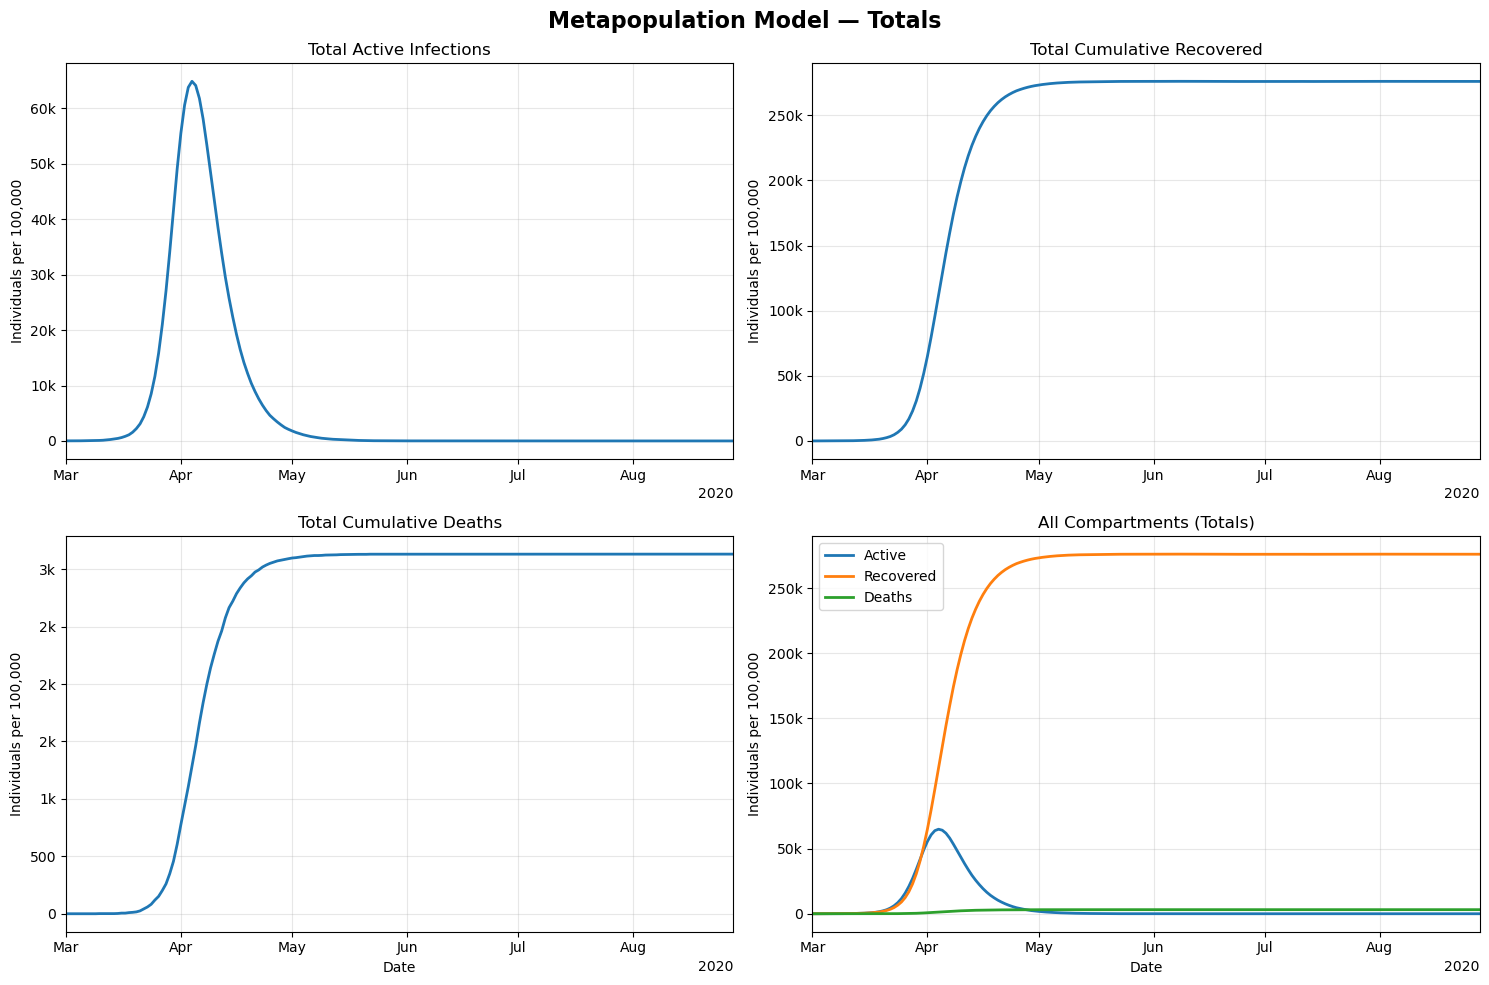

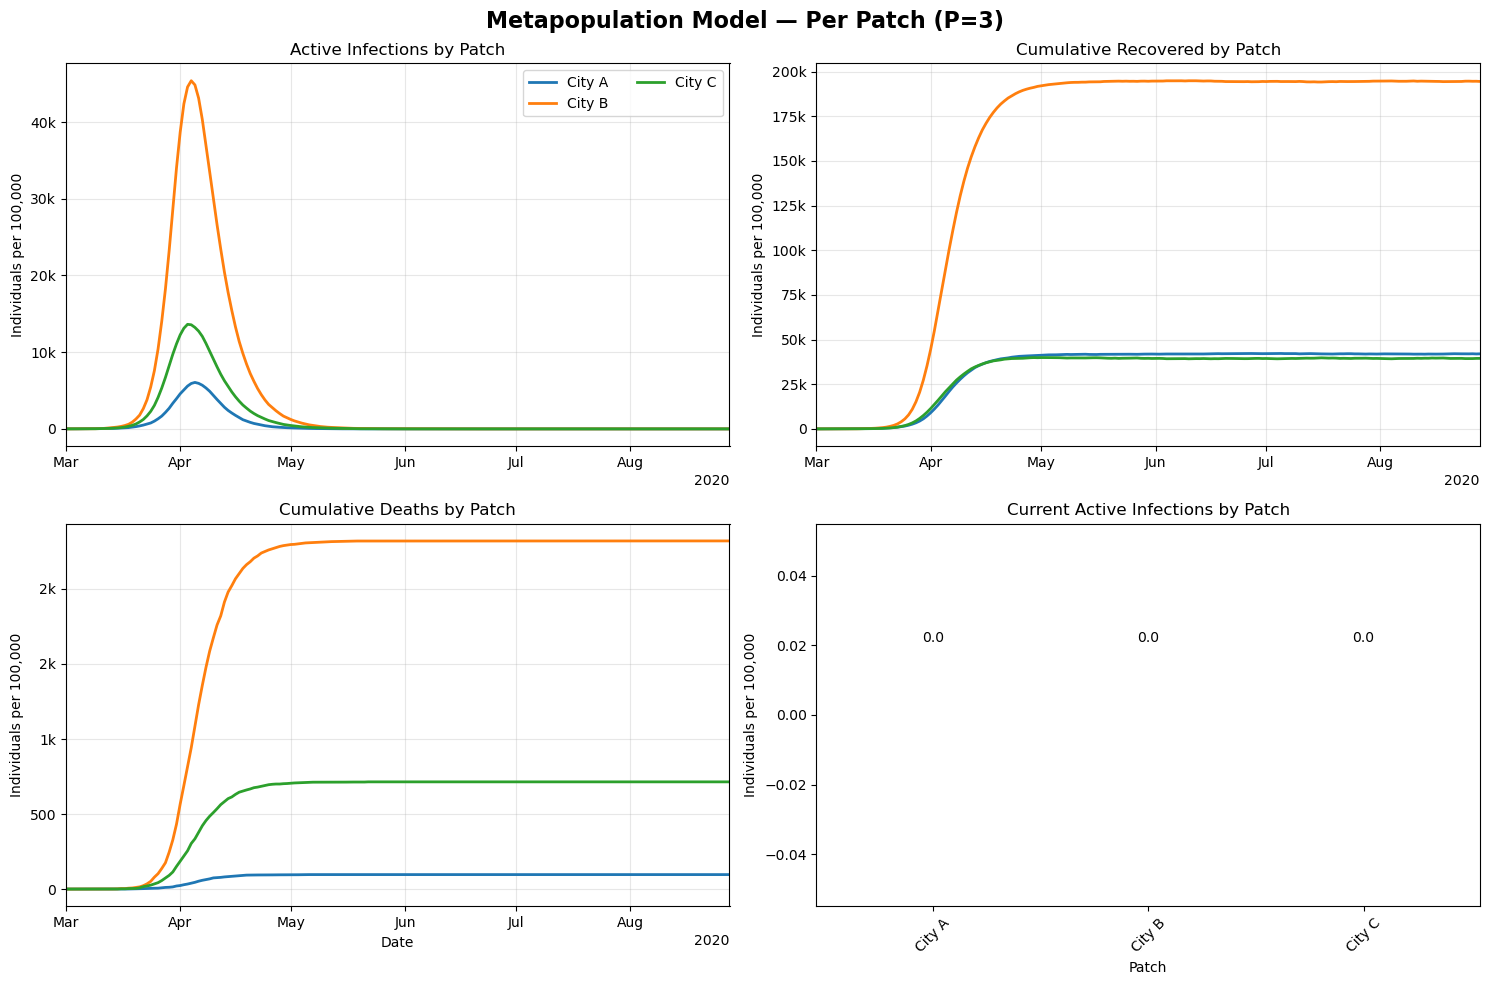

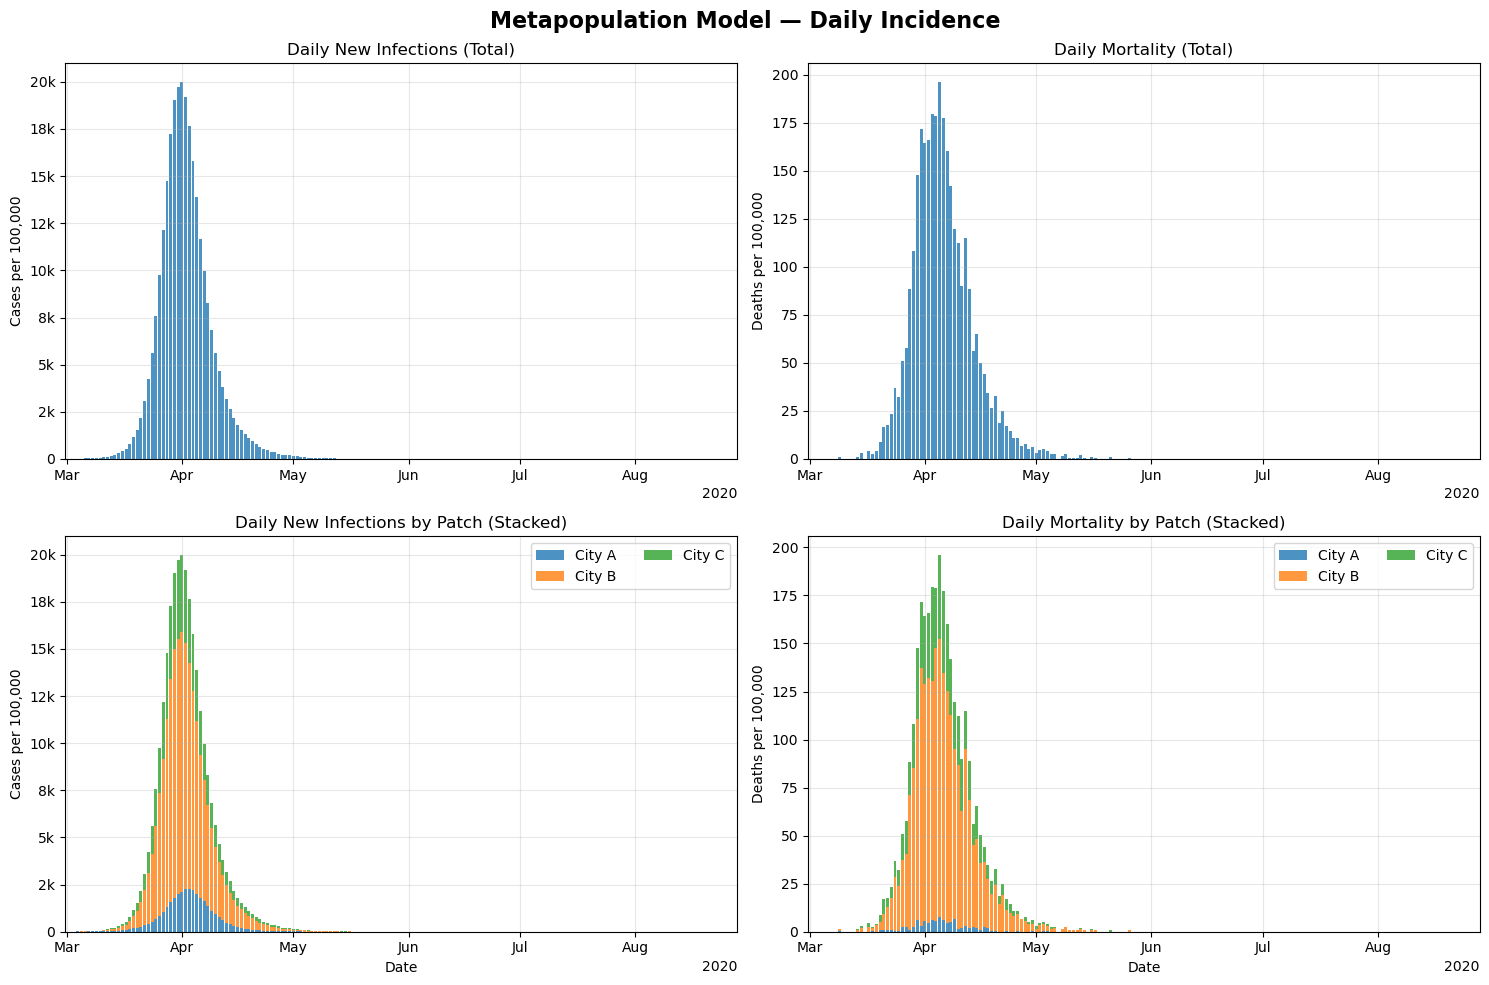

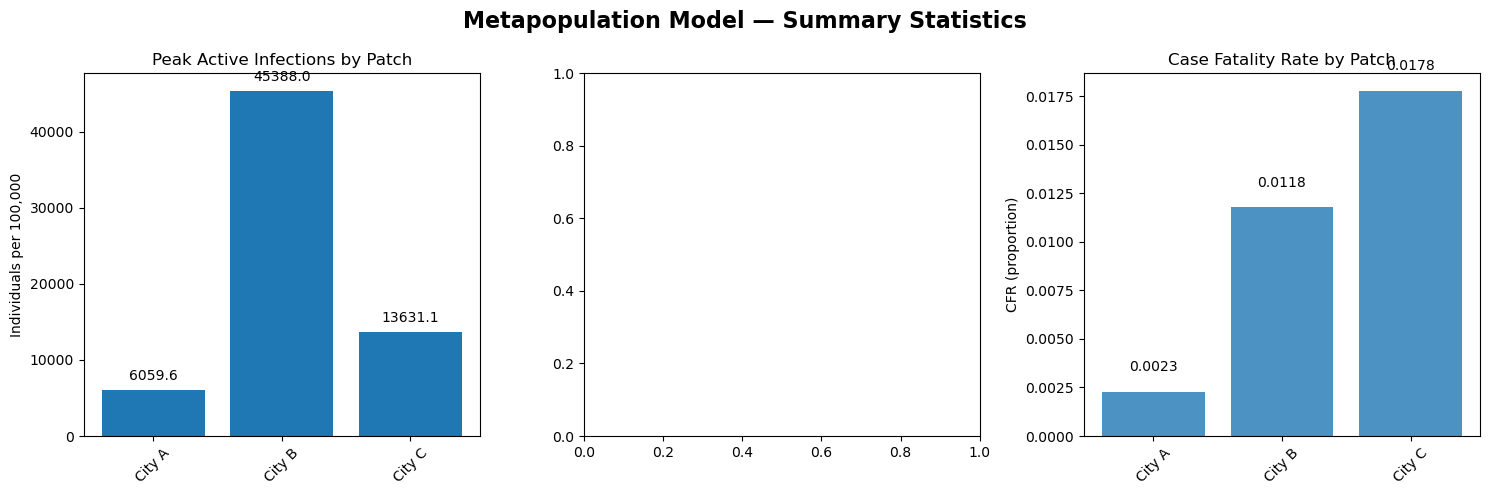


METAPOPULATION MODEL SUMMARY
Number of patches: 3
Simulation period: 181 days
Total final active infections: 0 (per 100,000)
Total cumulative recovered:   275974 (per 100,000)
Total cumulative deaths:      3131 (per 100,000)

Per-patch final active infections (per 100,000):
  City A: 0.0
  City B: 0.0
  City C: 0.0

Plots saved to: E:\Umich\EpidSim\PINN\Data


{'data': {'t_daily': array([  0.,   1.,   2.,   3.,   4.,   5.,   6.,   7.,   8.,   9.,  10.,
          11.,  12.,  13.,  14.,  15.,  16.,  17.,  18.,  19.,  20.,  21.,
          22.,  23.,  24.,  25.,  26.,  27.,  28.,  29.,  30.,  31.,  32.,
          33.,  34.,  35.,  36.,  37.,  38.,  39.,  40.,  41.,  42.,  43.,
          44.,  45.,  46.,  47.,  48.,  49.,  50.,  51.,  52.,  53.,  54.,
          55.,  56.,  57.,  58.,  59.,  60.,  61.,  62.,  63.,  64.,  65.,
          66.,  67.,  68.,  69.,  70.,  71.,  72.,  73.,  74.,  75.,  76.,
          77.,  78.,  79.,  80.,  81.,  82.,  83.,  84.,  85.,  86.,  87.,
          88.,  89.,  90.,  91.,  92.,  93.,  94.,  95.,  96.,  97.,  98.,
          99., 100., 101., 102., 103., 104., 105., 106., 107., 108., 109.,
         110., 111., 112., 113., 114., 115., 116., 117., 118., 119., 120.,
         121., 122., 123., 124., 125., 126., 127., 128., 129., 130., 131.,
         132., 133., 134., 135., 136., 137., 138., 139., 140., 141., 142.,
      

In [3]:
# Visualize
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter, MaxNLocator
from datetime import datetime, timedelta
import numpy as np
from pathlib import Path


def plot_metapop_data(
    data_dict=None,
    data_dir="PINN/Data",
    prefix="sim_",
    P=None,
    start_date="2020-03-01",
    figsize=(15, 10),
    save_plots=True,
    plot_total=True,
    plot_per_patch=True,
    plot_incidence=True,
    # --- new/optional ---
    patch_labels=None,
    per_capita=False,
    per_capita_scale=100_000,
    population_by_patch=None,  # used if per_capita and data_dict is None
    rolling_window=7,          # for MA in single-patch incidence
    ylog=False,                # log scale for totals & per-patch curves
    dpi=300,
    file_tag=None              # appended to output filenames if provided
):
    """
    Plot the generated metapopulation SIR/SEIR + Death (D) data.

    Parameters (existing):
    ----------------------
    data_dict : dict returned by generate_pinn_series_metapop(), or None to load from files
    data_dir, prefix, P, start_date, figsize, save_plots, plot_total, plot_per_patch, plot_incidence

    New / notable:
    --------------
    patch_labels : list[str] of length P, labels for patches (defaults to "Patch i")
    per_capita : bool, if True scale series by per_capita_scale / population
    per_capita_scale : int, scaling base (default 100k)
    population_by_patch : array-like length P, only needed if per_capita=True and data_dict is None
    rolling_window : int, window for moving average in single-patch incidence view
    ylog : bool, use log scale for totals/per-patch line charts
    dpi : int, dpi for saved figs
    file_tag : str, optional suffix for output filenames

    Returns:
    --------
    dict with 'data' (arrays, dates) and 'plots' (figure objects)
    """

    # ----------------------------
    # helpers
    # ----------------------------
    def _format_date_axis(ax):
        loc = mdates.AutoDateLocator(minticks=5, maxticks=10)
        ax.xaxis.set_major_locator(loc)
        ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(loc))
        ax.margins(x=0)

    def _kfmt(x, pos):
        # thousand/compact formatter
        if x >= 1e6: return f"{x/1e6:.1f}M"
        if x >= 1e3: return f"{x/1e3:.0f}k"
        return f"{int(x)}"

    def _maybe_log(ax):
        if ylog:
            ax.set_yscale("log")
            ax.yaxis.set_major_locator(MaxNLocator(nbins=6, prune=None))

    def _savefig(fig, fname):
        if save_plots:
            fig.savefig(data_dir / fname, dpi=dpi, bbox_inches="tight")

    def _as_np(a):
        return np.asarray(a) if a is not None else None

    # ----------------------------
    # load data (dict or files)
    # ----------------------------
    data_dir = Path(data_dir)
    if data_dict is not None:
        t_daily   = data_dict["t_daily"]             # (T+1,)
        I_active  = data_dict["I_active"]            # (T+1,P)
        R_cum     = data_dict["R_cum"]               # (T+1,P)
        D_cum     = data_dict["D_cum"]               # (T+1,P)
        I_new     = data_dict.get("I_new", np.zeros((0, 0), dtype=int))
        D_new     = data_dict.get("D_new", np.zeros((0, 0), dtype=int))
        states_d  = data_dict.get("states_daily", None)  # (T+1,P,C) if present
        P         = I_active.shape[1]
    else:
        # Infer P if needed
        if P is None:
            P = 0
            while (data_dir / f"{prefix}Infectious_p{P}.txt").exists():
                P += 1
            if P == 0:
                raise ValueError("Could not find any patch files. Check data_dir and prefix.")

        # Load per-patch series
        I_active = np.zeros((0, P))
        R_cum    = np.zeros((0, P))
        D_cum    = np.zeros((0, P))
        I_new    = np.zeros((0, P))
        D_new    = np.zeros((0, P))

        for p in range(P):
            I_p = np.loadtxt(data_dir / f"{prefix}Infectious_p{p}.txt")
            R_p = np.loadtxt(data_dir / f"{prefix}Recovered_p{p}.txt")
            D_p = np.loadtxt(data_dir / f"{prefix}Death_p{p}.txt")

            if I_active.shape[0] == 0:
                Tlen = len(I_p)
                I_active = np.zeros((Tlen, P))
                R_cum    = np.zeros((Tlen, P))
                D_cum    = np.zeros((Tlen, P))
                t_daily  = np.arange(Tlen, dtype=float)

            I_active[:, p] = I_p
            R_cum[:, p]    = R_p
            D_cum[:, p]    = D_p

            # Optional: load incidences if present
            inc_path = data_dir / f"{prefix}Incidence_p{p}.txt"
            mort_path = data_dir / f"{prefix}Mortality_p{p}.txt"
            if inc_path.exists() and mort_path.exists():
                if I_new.shape[0] == 0:
                    I_new = np.zeros((len(I_p), P))
                    D_new = np.zeros((len(I_p), P))
                I_new[:, p] = np.loadtxt(inc_path)
                D_new[:, p] = np.loadtxt(mort_path)

        states_d = None  # not available from files

    # ----------------------------
    # dates & labels
    # ----------------------------
    start_dt = datetime.strptime(start_date, "%Y-%m-%d")
    dates = np.array([start_dt + timedelta(days=int(d)) for d in t_daily], dtype=object)

    if patch_labels is None:
        patch_labels = [f"Patch {p}" for p in range(P)]
    else:
        if len(patch_labels) != P:
            raise ValueError(f"patch_labels must have length {P}")

    # ----------------------------
    # per-capita scaling if requested
    # ----------------------------
    N0 = None
    if per_capita:
        if states_d is not None:
            # Initial population per patch from states_daily at t=0 (includes D=0 initially)
            N0 = states_d[0].sum(axis=1).astype(float)  # shape (P,)
        else:
            if population_by_patch is None:
                raise ValueError("per_capita=True requires data_dict with states_daily "
                                 "or population_by_patch when loading from files.")
            N0 = _as_np(population_by_patch).astype(float)
            if N0.shape != (P,):
                raise ValueError(f"population_by_patch must be length-{P}")

        def _pc(a):
            # a: (T+1,P)
            return (a / N0) * per_capita_scale

        I_active_pc = _pc(I_active)
        R_cum_pc    = _pc(R_cum)
        D_cum_pc    = _pc(D_cum)
        I_new_pc    = _pc(I_new) if I_new.size else I_new
        D_new_pc    = _pc(D_new) if D_new.size else D_new
        ylab_abs   = f"Individuals per {per_capita_scale:,}"
    else:
        I_active_pc = I_active
        R_cum_pc    = R_cum
        D_cum_pc    = D_cum
        I_new_pc    = I_new
        D_new_pc    = D_new
        ylab_abs    = "Number of individuals"

    # output name suffix
    tag = f"_{file_tag}" if file_tag else ""
    unit_tag = "_percap" if per_capita else "_abs"

    plots_info = {}

    # ----------------------------
    # 1) Total series
    # ----------------------------
    if plot_total:
        fig, axes = plt.subplots(2, 2, figsize=figsize)
        fig.suptitle('Metapopulation Model — Totals', fontsize=16, fontweight='bold')

        # Total Active
        axes[0, 0].plot(dates, I_active_pc.sum(axis=1), linewidth=2, label='Active Infections')
        axes[0, 0].set_title('Total Active Infections')
        axes[0, 0].set_ylabel(ylab_abs)
        _format_date_axis(axes[0, 0]); _maybe_log(axes[0, 0]); axes[0, 0].yaxis.set_major_formatter(FuncFormatter(_kfmt))
        axes[0, 0].grid(True, alpha=0.3)

        # Total Recovered
        axes[0, 1].plot(dates, R_cum_pc.sum(axis=1), linewidth=2, label='Cumulative Recovered')
        axes[0, 1].set_title('Total Cumulative Recovered')
        axes[0, 1].set_ylabel(ylab_abs)
        _format_date_axis(axes[0, 1]); _maybe_log(axes[0, 1]); axes[0, 1].yaxis.set_major_formatter(FuncFormatter(_kfmt))
        axes[0, 1].grid(True, alpha=0.3)

        # Total Deaths
        axes[1, 0].plot(dates, D_cum_pc.sum(axis=1), linewidth=2, label='Cumulative Deaths')
        axes[1, 0].set_title('Total Cumulative Deaths')
        axes[1, 0].set_ylabel(ylab_abs)
        axes[1, 0].set_xlabel('Date')
        _format_date_axis(axes[1, 0]); _maybe_log(axes[1, 0]); axes[1, 0].yaxis.set_major_formatter(FuncFormatter(_kfmt))
        axes[1, 0].grid(True, alpha=0.3)

        # All together
        axes[1, 1].plot(dates, I_active_pc.sum(axis=1), linewidth=2, label='Active')
        axes[1, 1].plot(dates, R_cum_pc.sum(axis=1), linewidth=2, label='Recovered')
        axes[1, 1].plot(dates, D_cum_pc.sum(axis=1), linewidth=2, label='Deaths')
        axes[1, 1].set_title('All Compartments (Totals)')
        axes[1, 1].set_ylabel(ylab_abs)
        axes[1, 1].set_xlabel('Date')
        axes[1, 1].legend()
        _format_date_axis(axes[1, 1]); _maybe_log(axes[1, 1]); axes[1, 1].yaxis.set_major_formatter(FuncFormatter(_kfmt))
        axes[1, 1].grid(True, alpha=0.3)

        fig.tight_layout()
        _savefig(fig, f"metapop_total_compartments{tag}{unit_tag}.png")
        plots_info['total_compartments'] = fig

    # ----------------------------
    # 2) Per‑patch curves
    # ----------------------------
    if plot_per_patch and P > 1:
        colors = plt.cm.tab10(np.linspace(0, 1, max(P, 3)))  # stable default

        fig, axes = plt.subplots(2, 2, figsize=figsize)
        fig.suptitle(f'Metapopulation Model — Per Patch (P={P})', fontsize=16, fontweight='bold')

        # Infectious by patch
        for p in range(P):
            axes[0, 0].plot(dates, I_active_pc[:, p], linewidth=2, label=patch_labels[p])
        axes[0, 0].set_title('Active Infections by Patch')
        axes[0, 0].set_ylabel(ylab_abs)
        axes[0, 0].legend(ncol=2)
        _format_date_axis(axes[0, 0]); _maybe_log(axes[0, 0]); axes[0, 0].yaxis.set_major_formatter(FuncFormatter(_kfmt))
        axes[0, 0].grid(True, alpha=0.3)

        # Recovered by patch
        for p in range(P):
            axes[0, 1].plot(dates, R_cum_pc[:, p], linewidth=2, label=patch_labels[p])
        axes[0, 1].set_title('Cumulative Recovered by Patch')
        axes[0, 1].set_ylabel(ylab_abs)
        _format_date_axis(axes[0, 1]); _maybe_log(axes[0, 1]); axes[0, 1].yaxis.set_major_formatter(FuncFormatter(_kfmt))
        axes[0, 1].grid(True, alpha=0.3)

        # Deaths by patch
        for p in range(P):
            axes[1, 0].plot(dates, D_cum_pc[:, p], linewidth=2, label=patch_labels[p])
        axes[1, 0].set_title('Cumulative Deaths by Patch')
        axes[1, 0].set_ylabel(ylab_abs)
        axes[1, 0].set_xlabel('Date')
        _format_date_axis(axes[1, 0]); _maybe_log(axes[1, 0]); axes[1, 0].yaxis.set_major_formatter(FuncFormatter(_kfmt))
        axes[1, 0].grid(True, alpha=0.3)

        # Current active infections bar chart
        patch_names = patch_labels
        current_vals = I_active_pc[-1, :]
        bars = axes[1, 1].bar(patch_names, current_vals)
        axes[1, 1].set_title('Current Active Infections by Patch')
        axes[1, 1].set_ylabel(ylab_abs)
        axes[1, 1].set_xlabel('Patch')
        axes[1, 1].tick_params(axis='x', rotation=45)
        ymax = float(np.max(current_vals)) if current_vals.size else 0.0
        yoff = (ymax if ymax > 0 else 1.0) * 0.02
        for bar, val in zip(bars, current_vals):
            axes[1, 1].text(bar.get_x() + bar.get_width()/2., bar.get_height() + yoff,
                            f'{val:.0f}' if not per_capita else f'{val:.1f}', ha='center', va='bottom')

        fig.tight_layout()
        _savefig(fig, f"metapop_per_patch_compartments{tag}{unit_tag}.png")
        plots_info['per_patch_compartments'] = fig

    # ----------------------------
    # 3) Incidence / Mortality
    # ----------------------------
    if plot_incidence and I_new_pc.size and (I_new_pc.sum() > 0 or D_new_pc.sum() > 0):
        fig, axes = plt.subplots(2, 2, figsize=figsize)
        fig.suptitle('Metapopulation Model — Daily Incidence', fontsize=16, fontweight='bold')

        # Total daily incidence
        axes[0, 0].bar(dates, I_new_pc.sum(axis=1), alpha=0.8, label='New Infections')
        axes[0, 0].set_title('Daily New Infections (Total)')
        axes[0, 0].set_ylabel(ylab_abs if not per_capita else f'Cases per {per_capita_scale:,}')
        _format_date_axis(axes[0, 0]); axes[0, 0].yaxis.set_major_formatter(FuncFormatter(_kfmt))
        axes[0, 0].grid(True, alpha=0.3)

        # Total daily mortality
        axes[0, 1].bar(dates, D_new_pc.sum(axis=1), alpha=0.8, label='New Deaths')
        axes[0, 1].set_title('Daily Mortality (Total)')
        axes[0, 1].set_ylabel(ylab_abs if not per_capita else f'Deaths per {per_capita_scale:,}')
        _format_date_axis(axes[0, 1]); axes[0, 1].yaxis.set_major_formatter(FuncFormatter(_kfmt))
        axes[0, 1].grid(True, alpha=0.3)

        if P > 1:
            # Stacked new infections by patch
            bottom = np.zeros(len(dates))
            for p in range(P):
                axes[1, 0].bar(dates, I_new_pc[:, p], bottom=bottom, alpha=0.8, label=patch_labels[p])
                bottom += I_new_pc[:, p]
            axes[1, 0].set_title('Daily New Infections by Patch (Stacked)')
            axes[1, 0].set_ylabel(ylab_abs if not per_capita else f'Cases per {per_capita_scale:,}')
            axes[1, 0].set_xlabel('Date')
            axes[1, 0].legend(ncol=2)
            _format_date_axis(axes[1, 0]); axes[1, 0].yaxis.set_major_formatter(FuncFormatter(_kfmt))
            axes[1, 0].grid(True, alpha=0.3)

            # Stacked mortality by patch
            bottom = np.zeros(len(dates))
            for p in range(P):
                axes[1, 1].bar(dates, D_new_pc[:, p], bottom=bottom, alpha=0.8, label=patch_labels[p])
                bottom += D_new_pc[:, p]
            axes[1, 1].set_title('Daily Mortality by Patch (Stacked)')
            axes[1, 1].set_ylabel(ylab_abs if not per_capita else f'Deaths per {per_capita_scale:,}')
            axes[1, 1].set_xlabel('Date')
            axes[1, 1].legend(ncol=2)
            _format_date_axis(axes[1, 1]); axes[1, 1].yaxis.set_major_formatter(FuncFormatter(_kfmt))
            axes[1, 1].grid(True, alpha=0.3)
        else:
            # Single patch with moving averages
            if len(I_new_pc) >= max(rolling_window, 2):
                kernel = np.ones(rolling_window) / rolling_window
                ma_inf = np.convolve(I_new_pc.flatten(), kernel, mode='valid')
                ma_dea = np.convolve(D_new_pc.flatten(), kernel, mode='valid') if D_new_pc.size else np.zeros_like(ma_inf)
                ma_dates = dates[rolling_window-1:]

                axes[1, 0].plot(ma_dates, ma_inf, linewidth=2, label=f'{rolling_window}-day MA')
                axes[1, 0].bar(dates, I_new_pc.flatten(), alpha=0.3)
                axes[1, 0].set_title('New Infections with Moving Average')
                axes[1, 0].set_ylabel(ylab_abs if not per_capita else f'Cases per {per_capita_scale:,}')
                axes[1, 0].set_xlabel('Date')
                axes[1, 0].legend()
                _format_date_axis(axes[1, 0]); axes[1, 0].yaxis.set_major_formatter(FuncFormatter(_kfmt))
                axes[1, 0].grid(True, alpha=0.3)

                axes[1, 1].plot(ma_dates, ma_dea, linewidth=2, label=f'{rolling_window}-day MA')
                axes[1, 1].bar(dates, D_new_pc.flatten(), alpha=0.3)
                axes[1, 1].set_title('New Deaths with Moving Average')
                axes[1, 1].set_ylabel(ylab_abs if not per_capita else f'Deaths per {per_capita_scale:,}')
                axes[1, 1].set_xlabel('Date')
                axes[1, 1].legend()
                _format_date_axis(axes[1, 1]); axes[1, 1].yaxis.set_major_formatter(FuncFormatter(_kfmt))
                axes[1, 1].grid(True, alpha=0.3)

        fig.tight_layout()
        _savefig(fig, f"metapop_daily_incidence{tag}{unit_tag}.png")
        plots_info['incidence'] = fig

    # ----------------------------
    # 4) Summary statistics
    # ----------------------------
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle('Metapopulation Model — Summary Statistics', fontsize=16, fontweight='bold')

    # Peak infections by patch
    if P > 1:
        peak_vals = I_active_pc.max(axis=0)
        bars = axes[0].bar(patch_labels, peak_vals)
        axes[0].set_title('Peak Active Infections by Patch')
        axes[0].set_ylabel(ylab_abs)
        axes[0].tick_params(axis='x', rotation=45)
        ymax = float(np.max(peak_vals))
        yoff = (ymax if ymax > 0 else 1.0) * 0.02
        for bar, val in zip(bars, peak_vals):
            axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + yoff,
                         f'{val:.0f}' if not per_capita else f'{val:.1f}', ha='center', va='bottom')
    else:
        axes[0].text(0.5, 0.5, 'Single Patch\nAnalysis', transform=axes[0].transAxes,
                     ha='center', va='center', fontsize=14)
        axes[0].set_title('Patch Configuration')

    # Attack rate (final (R + D) / N0)
    if data_dict is not None:
        if per_capita and N0 is not None:
            N_total = N0
        else:
            # derive from states_daily if present; else from final totals (approx)
            if states_d is not None:
                N_total = states_d[0].sum(axis=1).astype(float)
            else:
                # best-effort: use (R + D + I) final
                N_total = (R_cum[-1, :] + D_cum[-1, :] + I_active[-1, :]).astype(float)
                N_total[N_total == 0] = 1.0
        attack_rate = (R_cum[-1, :] + D_cum[-1, :]) / N_total

        if P > 1:
            bars = axes[1].bar(patch_labels, attack_rate, alpha=0.8)
            axes[1].set_title('Attack Rate by Patch')
            axes[1].set_ylabel('Attack Rate (proportion)')
            axes[1].set_ylim(0, 1)
            axes[1].tick_params(axis='x', rotation=45)
            for bar, val in zip(bars, attack_rate):
                axes[1].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
                             f'{val:.3f}', ha='center', va='bottom')
        else:
            axes[1].text(0.5, 0.5, f'Attack Rate:\n{attack_rate[0]:.3f}',
                         transform=axes[1].transAxes, ha='center', va='center', fontsize=14)
            axes[1].set_title('Overall Attack Rate')

    # Case fatality rate
    denom = (R_cum[-1, :] + D_cum[-1, :])
    cfr = np.divide(D_cum[-1, :], denom, out=np.zeros_like(denom, dtype=float), where=(denom > 0))
    if P > 1:
        bars = axes[2].bar(patch_labels, cfr, alpha=0.8)
        axes[2].set_title('Case Fatality Rate by Patch')
        axes[2].set_ylabel('CFR (proportion)')
        axes[2].tick_params(axis='x', rotation=45)
        ymax = float(np.max(cfr))
        yoff = (ymax if ymax > 0 else 0.01) * 0.05
        for bar, val in zip(bars, cfr):
            axes[2].text(bar.get_x() + bar.get_width()/2., bar.get_height() + yoff,
                         f'{val:.4f}', ha='center', va='bottom')
    else:
        axes[2].text(0.5, 0.5, f'CFR:\n{cfr[0]:.4f}',
                     transform=axes[2].transAxes, ha='center', va='center', fontsize=14)
        axes[2].set_title('Case Fatality Rate')

    fig.tight_layout()
    _savefig(fig, f"metapop_summary_statistics{tag}{unit_tag}.png")
    plots_info['summary_statistics'] = fig

    # Show all plots
    plt.show()

    # Summary printout
    total_final_I = float(I_active_pc.sum(axis=1)[-1])
    total_final_R = float(R_cum_pc.sum(axis=1)[-1])
    total_final_D = float(D_cum_pc.sum(axis=1)[-1])

    print(f"\n{'=' * 60}")
    print(f"METAPOPULATION MODEL SUMMARY")
    print(f"{'=' * 60}")
    print(f"Number of patches: {P}")
    print(f"Simulation period: {len(t_daily)} days")
    unit_str = f"per {per_capita_scale:,}" if per_capita else "individuals"
    print(f"Total final active infections: {total_final_I:.0f} ({unit_str})")
    print(f"Total cumulative recovered:   {total_final_R:.0f} ({unit_str})")
    print(f"Total cumulative deaths:      {total_final_D:.0f} ({unit_str})")

    if P > 1:
        print(f"\nPer-patch final active infections ({unit_str}):")
        for name, val in zip(patch_labels, I_active_pc[-1, :]):
            print(f"  {name}: {val:.1f}" if per_capita else f"  {name}: {int(val)}")

    if save_plots:
        print(f"\nPlots saved to: {data_dir.resolve()}")

    return {
        'data': {
            't_daily': t_daily,
            'dates': dates,
            'I_active': I_active_pc,
            'R_cum': R_cum_pc,
            'D_cum': D_cum_pc,
            'I_new': I_new_pc,
            'D_new': D_new_pc,
            'P': P,
            'patch_labels': patch_labels,
            'per_capita': per_capita,
            'per_capita_scale': per_capita_scale
        },
        'plots': plots_info
    }


plot_metapop_data(
    data_dir="PINN/Data",
    prefix="sim_",
    P=3,
    start_date="2020-03-01",
    patch_labels=["City A", "City B", "City C"],
    per_capita=True,
    population_by_patch=[200_030, 150_000, 180_000]  # must match P
)


In [1]:
# -*- coding: utf-8 -*-
def offdiag_mask(P):
    m = np.ones((P,P), dtype=np.float64)
    np.fill_diagonal(m, 0.0)
    return m

def make_bin_gating(t_f, B, lb, ub):
    lb_ = float(lb); ub_ = float(ub)
    edges = np.linspace(lb_, ub_, B+1)
    tt = t_f.reshape(-1)
    idx = np.searchsorted(edges, tt, side='right') - 1
    idx = np.clip(idx, 0, B-1)
    G = np.zeros((len(tt), B), dtype=np.float64)
    G[np.arange(len(tt)), idx] = 1.0
    return G, edges

class PhysicsInformedNN_Metapop:
    """
    Metapopulation fractional SIR+D PINN with unknown movement M(t).
    This revision estimates **per‑patch** parameters:
      - Beta_p(t) time‑varying for each patch (NN with P outputs)
      - gamma_p and mu_p (trainable, nonnegative per patch)
    """

    def __init__(self, P, N_vec,
                 t_f, t_train,
                 I_train, R_train, D_train,
                 U0, lb, ub,
                 layers, layers_Beta,
                 B_bins=1,
                 lambda_M=1e-4,
                 seed=1234,
                 # ---- NEW hyperparameters ----
                 beta_lo=0.0, beta_hi=1.2,         # cap β_p(t) into [beta_lo, beta_hi]
                 M_max=0.08,                       # cap movement rates per edge (per day)
                 lambda_beta_smooth=1e-3,          # β_t smoothness
                 lambda_M_sym=1e-4,                # symmetry prior on M (≈ undirected flows)
                 lambda_M_row=1e-4, M_row_cap=0.10,# total outflow cap per patch
                 lambda_kappa=5e-3,                # keep κ close to 1 (ODE-like)
                 adam_lr=2e-3,                     # Adam LR
                 Mort_train=None):

        tf.set_random_seed(seed)

        self.beta_lo = float(beta_lo); self.beta_hi = float(beta_hi)
        self.M_max = None if M_max is None else float(M_max)
        self.lambda_beta_smooth = float(lambda_beta_smooth)
        self.lambda_M_sym = float(lambda_M_sym)
        self.lambda_M_row = float(lambda_M_row); self.M_row_cap = float(M_row_cap)
        self.lambda_kappa = float(lambda_kappa)
        self.adam_lr = float(adam_lr)
        np.random.seed(seed)

        self.P = P
        self.N_vec = np.asarray(N_vec, dtype=np.float64).reshape(1, P)
        self.B_bins = int(B_bins)
        self.lambda_M = float(lambda_M)

        # Data
        self.t_f = np.asarray(t_f, dtype=np.float64)
        self.t_train = np.asarray(t_train, dtype=np.float64)
        self.I_train = np.asarray(I_train, dtype=np.float64)
        self.R_train = np.asarray(R_train, dtype=np.float64)
        self.D_train = np.asarray(D_train, dtype=np.float64)
        self.Mort_train = None if Mort_train is None else np.asarray(Mort_train, dtype=np.float64)

        self.S0 = np.asarray(U0[0], dtype=np.float64).reshape(1,P)
        self.I0 = np.asarray(U0[1], dtype=np.float64).reshape(1,P)
        self.R0 = np.asarray(U0[2], dtype=np.float64).reshape(1,P)
        self.D0 = np.asarray(U0[3], dtype=np.float64).reshape(1,P)

        # Time discretization for fractional derivative
        self.M = len(self.t_f) - 1
        self.tau = self.t_f[1,0] - self.t_f[0,0]

        # Bounds for input normalization
        self.lb = lb
        self.ub = ub

        # TF session
        self.sess = tf.Session(config=tf.ConfigProto(allow_soft_placement=True,
                                                     log_device_placement=False))

        # Placeholders
        self.t_tf = tf.placeholder(tf.float64, shape=[None, 1])     # residual grid
        self.t_u  = tf.placeholder(tf.float64, shape=[None, 1])     # observed times
        self.I_u  = tf.placeholder(tf.float64, shape=[None, self.P])
        self.R_u  = tf.placeholder(tf.float64, shape=[None, self.P])
        self.D_u  = tf.placeholder(tf.float64, shape=[None, self.P])
        self.Mort_u = tf.placeholder(tf.float64, shape=[None, self.P])

        self.S0_u = tf.placeholder(tf.float64, shape=[None, self.P])  # (1,P)
        self.I0_u = tf.placeholder(tf.float64, shape=[None, self.P])
        self.R0_u = tf.placeholder(tf.float64, shape=[None, self.P])
        self.D0_u = tf.placeholder(tf.float64, shape=[None, self.P])

        # --------------------------
        # Per‑patch parameters  <<< NEW
        # --------------------------
        # gamma_p and mu_p as vectors (length P), strictly positive via softplus
        init_gamma = np.log(np.exp(0.05) - 1.0) * np.ones(self.P)   # ~0.05
        init_mu    = np.log(np.exp(0.003) - 1.0) * np.ones(self.P)
        self.gamma_raw = tf.Variable(init_gamma, dtype=tf.float64)
        self.mu_raw    = tf.Variable(init_mu,    dtype=tf.float64)
        self.a_vec = tf.nn.softplus(self.gamma_raw)                 # shape (P,)
        self.b_vec = tf.nn.softplus(self.mu_raw)                    # shape (P,)
        # Broadcast over time as (T,P) when needed
        self.a_row = tf.reshape(self.a_vec, [1, self.P])            # (1,P)
        self.b_row = tf.reshape(self.b_vec, [1, self.P])            # (1,P)
        self.beta_raw = tf.Variable(np.zeros(self.P), dtype=tf.float64)
        self.beta_vec = self.beta_lo + (self.beta_hi - self.beta_lo) * tf.sigmoid(self.beta_raw)  # (P,)
        self.beta_row = tf.reshape(self.beta_vec, [1, self.P])  # (1,P), easy to broadcast over time

        # Population per patch (1,P)
        self.N_tf = tf.constant(self.N_vec, dtype=tf.float64)

        # Networks
        self.weights, self.biases = self.initialize_NN(layers)
        self.weights_Beta, self.biases_Beta = self.initialize_NN(layers_Beta)  # <<< CHANGED: output P

        # --- Constant kappas (shared across patches, as before) ---
        self.kappa1_raw = tf.Variable(0.0, dtype=tf.float64, trainable=True)
        self.kappa2_raw = tf.Variable(0.0, dtype=tf.float64, trainable=True)
        self.kappa3_raw = tf.Variable(0.0, dtype=tf.float64, trainable=True)
        self.kappa4_raw = tf.Variable(0.0, dtype=tf.float64, trainable=True)
        self.kappa1 = 0.2 + 0.8*tf.sigmoid(self.kappa1_raw)
        self.kappa2 = 0.2 + 0.8*tf.sigmoid(self.kappa2_raw)
        self.kappa3 = 0.2 + 0.8*tf.sigmoid(self.kappa3_raw)
        self.kappa4 = 0.2 + 0.8*tf.sigmoid(self.kappa4_raw)
        self.Kappa_pred1 = tf.ones_like(self.t_u, dtype=tf.float64) * self.kappa1
        self.Kappa_pred2 = tf.ones_like(self.t_u, dtype=tf.float64) * self.kappa2
        self.Kappa_pred3 = tf.ones_like(self.t_u, dtype=tf.float64) * self.kappa3
        self.Kappa_pred4 = tf.ones_like(self.t_u, dtype=tf.float64) * self.kappa4

        # Movement parameterization (piecewise‑constant per bin), nonnegative, zero diag
        mask_np = offdiag_mask(self.P)
        self.mask_offdiag = tf.constant(mask_np, dtype=tf.float64)
        self.M_raw = tf.Variable(tf.random_normal([self.B_bins, self.P, self.P],
                                                  stddev=1e-3, dtype=tf.float64), trainable=True)
        M_pos = (self.M_max * tf.sigmoid(self.M_raw)) if (self.M_max is not None) else tf.nn.softplus(self.M_raw)
        self.M_bins = M_pos * self.mask_offdiag

        # Gating for residual grid
        G_f_np, self.bin_edges = make_bin_gating(self.t_f, self.B_bins, float(lb), float(ub))
        self.G_f = tf.constant(G_f_np, dtype=tf.float64)               # (M+1,B)
        self.M_seq_f = tf.tensordot(self.G_f, self.M_bins, axes=[[1],[0]])  # (M+1,P,P)

        # Predictions on observed times
        self.S_pred, self.I_pred, self.R_pred, self.D_pred = self.net_u(self.t_u)    # (T,P)
        self.BetaP = self.net_BetaP(self.t_u)                                        # (T,P)
        D_inc_pred = self.D_pred[1:, :] - self.D_pred[:-1, :]     # (T-1, P)
        Mort_inc_true = self.Mort_u[1:, :]                        # (T-1, P)
        lambda_mort = 5e-3    # you can tune this
        self.lossMort = lambda_mort * tf.reduce_mean(tf.square(D_inc_pred - Mort_inc_true))

        self.S0_pred = self.S_pred[0:1, :]
        self.I0_pred = self.I_pred[0:1, :]
        self.R0_pred = self.R_pred[0:1, :]
        self.D0_pred = self.D_pred[0:1, :]

        # Residuals on t_f grid (fractional dynamic + movement)
        self.f_S, self.f_I, self.f_R, self.f_D, self.f_con = self.net_f(self.t_tf)

        # --- Regularizers / Priors ---
        #

        # (ii) Movement near-symmetry across i<->j (per bin)
        MbT = tf.transpose(self.M_bins, perm=[0, 2, 1])
        self.lossM_sym = self.lambda_M_sym * tf.reduce_mean(tf.abs(self.M_bins - MbT))

        # (iii) Row-sum (total outflow per patch) should not explode
        row_sum_bins = tf.reduce_sum(self.M_bins, axis=2)               # (B,P)
        excess = tf.nn.relu(row_sum_bins - self.M_row_cap)
        self.lossM_row = self.lambda_M_row * tf.reduce_mean(tf.square(excess))

        # (iv) Keep fractional orders close to 1 to avoid soaking up dynamics
        self.lossKappa = self.lambda_kappa * (
            tf.square(self.kappa1 - 1.0)
          + tf.square(self.kappa2 - 1.0)
          + tf.square(self.kappa3 - 1.0)
          + tf.square(self.kappa4 - 1.0)
        )


        # Losses (kept as in your code)
        self.lossU0 = tf.reduce_mean(tf.square(self.I0_u - self.I0_pred)) \
                    + tf.reduce_mean(tf.square(self.R0_u - self.R0_pred)) \
                    + tf.reduce_mean(tf.square(self.D0_u - self.D0_pred))
        self.lossU = 8.0*tf.reduce_mean(tf.square(self.I_pred - self.I_u)) \
                   + 1.0*tf.reduce_mean(tf.square(self.R_pred - self.R_u)) \
                   + 20.0*tf.reduce_mean(tf.square(self.D_pred - self.D_u)) \
                   + 20.0*self.lossMort
        self.lossF = tf.reduce_mean(tf.square(self.f_S)) \
                   + tf.reduce_mean(tf.square(self.f_I)) \
                   + tf.reduce_mean(tf.square(self.f_R)) \
                   + tf.reduce_mean(tf.square(self.f_D)) \
                   + tf.reduce_mean(tf.square(self.f_con))
        self.lossM_L1 = self.lambda_M * tf.reduce_mean(self.M_bins)
        self.loss = (1.0*self.lossU0 + 5.0*self.lossU + self.lossF
                     + self.lossM_L1 + self.lossM_sym + self.lossM_row
                     + self.lossKappa)

        # Optimizers
        all_vars = tf.trainable_variables()
        vars_move = [self.M_raw]
        vars_nomove = [v for v in all_vars if v not in vars_move ]


        opt = tf.train.AdamOptimizer(learning_rate=self.adam_lr)
        self.train_op_Adam        = opt.minimize(self.loss, var_list=all_vars)
        self.train_op_Adam_nomove = opt.minimize(self.loss, var_list=vars_nomove)

        self.optimizer = tf.contrib.opt.ScipyOptimizerInterface(
            self.loss, method='L-BFGS-B',
            options={'maxiter': 50000, 'maxfun': 50000, 'maxcor': 50,
                     'maxls': 50, 'ftol': 1.0 * np.finfo(float).eps})


        init = tf.global_variables_initializer()
        self.sess.run(init)
        self.saver = tf.train.Saver()

    # ---------- NN blocks ----------
    def initialize_NN(self, layers):
        weights, biases = [], []
        for l in range(0, len(layers)-1):
            W = self.xavier_init([layers[l], layers[l+1]])
            b = tf.Variable(tf.zeros([1, layers[l+1]], dtype=tf.float64), dtype=tf.float64)
            weights.append(W)
            biases.append(b)
        return weights, biases

    def xavier_init(self, size):
        in_dim, out_dim = size
        std = np.sqrt(2.0/(in_dim + out_dim))
        return tf.Variable(tf.truncated_normal([in_dim, out_dim], stddev=std, dtype=tf.float64), dtype=tf.float64)

    def neural_net(self, t, weights, biases):
        H = 2.0*(t-self.lb)/(self.ub-self.lb) - 1.0
        for l in range(0, len(weights)-1):
            H = tf.tanh(tf.add(tf.matmul(H, weights[l]), biases[l]))
        Y = tf.add(tf.matmul(H, weights[-1]), biases[-1])
        return Y

    def net_u(self, t):
        """
        Output S,I,R,D as positive counts per patch, without forcing
        S+I+R+D = N_p for each patch. We will enforce *global* conservation instead.
        """
        Y = self.neural_net(t, self.weights, self.biases)   # (T, 4P)
        logits = tf.reshape(Y, (-1, self.P, 4))             # (T, P, 4)
        SIRD_pos = tf.nn.softplus(logits) + 1e-12           # (T, P, 4) positivity only

        S = SIRD_pos[:, :, 0]
        I = SIRD_pos[:, :, 1]
        R = SIRD_pos[:, :, 2]
        D = SIRD_pos[:, :, 3]
        return S, I, R, D

    def net_BetaP(self, t):
        """Return a time-invariant per-patch beta; broadcast to len(t) rows."""
        T = tf.shape(t)[0]
        onesT = tf.ones([T, 1], dtype=tf.float64)
        return onesT * self.beta_row        # shape (T, P)

    # (Your Jacobi helpers kept for compatibility)
    def net_Kappa_plot(self, COEF):
        polys = tf.constant(np.transpose(Jacobi_polys_plots[:poly_order, :]), dtype=tf.float64)
        Kappa = tf.matmul(polys, COEF)
        return 0.2 + 0.8*tf.sigmoid(Kappa)

    def net_Kappa(self, COEF):
        polys = tf.constant(np.transpose(Jacobi_polys[:poly_order, :]), dtype=tf.float64)
        Kappa = tf.matmul(polys, COEF)
        return 0.2 + 0.8*tf.sigmoid(Kappa)

    # Fractional L1 coefficients (unchanged)
    def FDM1(self, Kappa):
        m = self.M
        Tau = self.tau
        kappa_vec = tf.reshape(Kappa, [m+1,1])
        kappa_mat = tf.tile(kappa_vec, [1, m-1])

        idx = np.tril_indices(m+1, k=-1)
        Temp1 = np.zeros([m+1, m+1]); Temp1[idx] = idx[0]-idx[1]; Temp1 = np.tril(Temp1, k=-2)
        Temp2 = -np.eye(m+1);         Temp2[idx] = idx[0]-idx[1]-1; Temp2 = np.tril(Temp2, k=-2)
        Temp3 = -2*np.eye(m+1);       Temp3[idx] = idx[0]-idx[1]-2; Temp3 = np.tril(Temp3, k=-2)

        A = np.concatenate((np.zeros((1,m)), np.eye(m)), axis=0); A = A[:,0:m-1]

        Temp1 = tf.constant(Temp1[:,0:m-1], dtype=tf.float64)
        Temp2 = tf.constant(Temp2[:,0:m-1], dtype=tf.float64)
        Temp3 = tf.constant(Temp3[:,0:m-1], dtype=tf.float64)
        A     = tf.constant(A, dtype=tf.float64)

        Temp = tf.pow(Temp1, 1.0-kappa_mat) - 2*tf.pow(Temp2, 1.0-kappa_mat) + tf.pow(Temp3, 1.0-kappa_mat) + A

        L_Temp1 = tf.pow(tf.reshape(tf.constant(np.arange(m),   dtype=tf.float64), [m,1]), 1.0-kappa_vec[1:m+1, 0:1])
        L_Temp2 = tf.pow(tf.reshape(tf.constant(np.arange(m)+1, dtype=tf.float64), [m,1]), 1.0-kappa_vec[1:m+1, 0:1])
        L_Temp  = tf.concat((tf.zeros((1,1), dtype=tf.float64), L_Temp1 - L_Temp2), axis=0)
        R_Temp  = tf.concat((tf.zeros((m,1), dtype=tf.float64), tf.ones((1,1), dtype=tf.float64)), axis=0)

        coeff_mat = tf.concat((L_Temp, Temp, R_Temp), axis=1)

        c = tf.tile(tf.math.divide(tf.pow(Tau, -kappa_vec), tf.exp(tf.lgamma(2-kappa_vec))),
                    multiples=tf.constant([1, m+1], dtype=tf.int32))
        coeff_mat = tf.multiply(c, coeff_mat)
        return coeff_mat  # (m+1, m+1)

    def net_f(self, t):
        """
        Residuals on the residual grid t_f (must call with t = self.t_tf).
        Vectorized across patches; includes movement M_seq_f.
        """
        # States
        S, I, R, D = self.net_u(t)  # (m+1,P)

        # Per‑patch Beta(t)
        rP = self.net_BetaP(t)      # (m+1,P)

        # Fractional derivatives (shared kappa, same as before)
        K1 = tf.ones([self.M+1,1], dtype=tf.float64) * self.kappa1
        K2 = tf.ones([self.M+1,1], dtype=tf.float64) * self.kappa2
        K3 = tf.ones([self.M+1,1], dtype=tf.float64) * self.kappa3
        K4 = tf.ones([self.M+1,1], dtype=tf.float64) * self.kappa4

        D1 = self.FDM1(K1); D2 = self.FDM1(K2); D3 = self.FDM1(K3); D4 = self.FDM1(K4)
        S_t = tf.matmul(D1, S)
        I_t = tf.matmul(D2, I)
        R_t = tf.matmul(D3, R)
        D_t = tf.matmul(D4, D)

        # fractional scaling
        Tsc = tf.constant(7.0, dtype=tf.float64)
        S_t = tf.pow(Tsc, K1-1.0)*S_t/tf.exp(tf.lgamma(1.0+K1))
        I_t = tf.pow(Tsc, K2-1.0)*I_t/tf.exp(tf.lgamma(1.0+K2))
        R_t = tf.pow(Tsc, K3-1.0)*R_t/tf.exp(tf.lgamma(1.0+K3))
        D_t = tf.pow(Tsc, K4-1.0)*D_t/tf.exp(tf.lgamma(1.0+K4))

        # Movement (inflow - outflow)
        row_sums = tf.reduce_sum(self.M_seq_f, axis=2)  # (m+1,P)
        infl_S = tf.einsum('tp,tpq->tq', S, self.M_seq_f)
        infl_I = tf.einsum('tp,tpq->tq', I, self.M_seq_f)
        infl_R = tf.einsum('tp,tpq->tq', R, self.M_seq_f)
        out_S  = S * row_sums
        out_I  = I * row_sums
        out_R  = R * row_sums
        move_S = infl_S - out_S
        move_I = infl_I - out_I
        move_R = infl_R - out_R

        # Incidence per patch
        eps = 1e-12
        N_live = S + I + R
        inc = rP * S * I / (N_live + eps)   # (m+1,P)

        # Broadcast per‑patch gamma/mu over time
        aP = tf.ones([tf.shape(S)[0], 1], dtype=tf.float64) * self.a_row   # (m+1,P)
        bP = tf.ones([tf.shape(S)[0], 1], dtype=tf.float64) * self.b_row   # (m+1,P)

        # Residuals (==0 ideally)
        f_S = S_t + inc - move_S
        f_I = I_t - inc + (aP + bP)*I - move_I
        f_R = R_t - aP*I - move_R
        f_D = D_t - bP*I

        # Mass conservation per patch
        N_total = tf.reduce_sum(self.N_tf)                             # scalar
        sum_all = tf.reduce_sum(S + I + R + D, axis=1, keepdims=True)  # (m+1, 1)
        f_con = sum_all - N_total                                      # (m+1, 1)

        return f_S, f_I, f_R, f_D, f_con

    # ---------- Training / Predict / Movement ----------
    def callback(self, loss, lossU0, lossU, lossF):
        print('Loss: %.3e, U0: %.3e, U: %.3e, F: %.3e' % (loss, lossU0, lossU, lossF))

    def train(self, nIter=10000, use_lbfgs=True, warmup_iters=2000):
        tf_dict = {
            self.t_u: self.t_train, self.t_tf: self.t_f,
            self.I_u: self.I_train, self.R_u: self.R_train, self.D_u: self.D_train,
            self.Mort_u: self.Mort_train,
            self.S0_u: self.S0, self.I0_u: self.I0, self.R0_u: self.R0, self.D0_u: self.D0
        }

        # ---- Warm-up: learn β, γ, μ, κ, states; freeze movement ----
        for it in range(max(0, warmup_iters)):
            self.sess.run(self.train_op_Adam_nomove, tf_dict)
            if it % 200 == 0:
                lv, lU = self.sess.run([self.loss, self.lossU], tf_dict)
                print(f"[WARMUP] it={it:5d}  loss={lv:.3e}  U={lU:.3e}")

        # ---- Full training (movement unfrozen) ----
        for it in range(nIter - warmup_iters + 1):
            self.sess.run(self.train_op_Adam, tf_dict)
            if it % 200 == 0:
                lv, lU, lF = self.sess.run([self.loss, self.lossU, self.lossF], tf_dict)
                print(f"[ADAM]   it={it:5d}  loss={lv:.3e}  U={lU:.3e}  F={lF:.3e}")

        if use_lbfgs:
            self.optimizer.minimize(self.sess, feed_dict=tf_dict,
                                    fetches=[self.loss, self.lossU0, self.lossU, self.lossF],
                                    loss_callback=self.callback)


    def predict(self, t_star):
        tf_dict = {self.t_u: t_star}
        S = self.sess.run(self.S_pred, tf_dict)
        I = self.sess.run(self.I_pred, tf_dict)
        R = self.sess.run(self.R_pred, tf_dict)
        D = self.sess.run(self.D_pred, tf_dict)
        BetaP = self.sess.run(self.BetaP, tf_dict)                        # <<< CHANGED
        K1 = self.sess.run(self.Kappa_pred1, {self.t_u: t_star})
        K2 = self.sess.run(self.Kappa_pred2, {self.t_u: t_star})
        K3 = self.sess.run(self.Kappa_pred3, {self.t_u: t_star})
        K4 = self.sess.run(self.Kappa_pred4, {self.t_u: t_star})
        return S, I, R, D, K1, K2, K3, K4, BetaP

    def movement_matrices(self):
        return self.sess.run(self.M_bins)

    # <<< NEW: fetch per‑patch scalars
    def patch_params(self):
        """Return dict with per‑patch gamma, mu, and constant beta (length-P arrays)."""
        a, b, beta = self.sess.run([self.a_vec, self.b_vec, self.beta_vec])
        return {"gamma": a, "mu": b, "beta": beta}

In [2]:
# train_metapop.py
import os
import numpy as np
import tensorflow as tf
from datetime import datetime
from scipy.special import jacobi

# -------------------------
# Configure paths & data
# -------------------------
data_dir = "PINN/Data"     # where your sim_* files were saved
prefix   = "sim_"          # e.g., sim_Infectious_p0.txt ...

# Discover P and T
def discover_P_T(data_dir, prefix):
    p = 0
    while os.path.exists(os.path.join(data_dir, f"{prefix}Infectious_p{p}.txt")):
        p += 1
    if p == 0:
        raise FileNotFoundError("No per-patch files found.")
    I0 = np.loadtxt(os.path.join(data_dir, f"{prefix}Infectious_p0.txt"))
    T = len(I0)
    return p, T

P, T = discover_P_T(data_dir, prefix)
print(f"Found P={P} patches, T={T} days")

# Load per-patch series (T,P)
def load_stack(var):
    X = []
    for p in range(P):
        arr = np.loadtxt(os.path.join(data_dir, f"{prefix}{var}_p{p}.txt"))
        X.append(arr.reshape(-1,1))
    return np.concatenate(X, axis=1)

I_star = load_stack("Infectious")
R_star = load_stack("Recovered")
D_star = load_stack("Death")
Mort_star = load_stack("Mortality")   # <-- NEW: daily death events per patch (D_new)


# -------------------------
# Scaling (like your script)
# -------------------------
sf = 1e-5   # adjust if needed
I_star = I_star * sf
R_star = R_star * sf
D_star = D_star * sf
Mort_star = Mort_star * sf
# You should provide N_vec per patch (scaled)
# If you still have the 'init' you used to simulate, pass its S0+I0+R0+D0 for each patch.
# Example (replace with your actual init):
# init = np.array([[200_000,30,0,0],[150_000,10,0,0],[180_000,5,0,0]])
# N_vec = init.sum(axis=1) * sf
# If not available, a rough proxy is to set N_vec to a large constant per patch.
# Here we read N from your simulation init example:
N_vec = np.array([200000,150000,180000], dtype=np.float64)[:P] * sf  # <-- EDIT to your true init

# Initial conditions from data at day 0
I0 = I_star[0:1, :]     # (1,P)
R0 = R_star[0:1, :]
D0 = D_star[0:1, :]
S0 = N_vec.reshape(1,P) - I0 - R0 - D0
U0 = [S0, I0, R0, D0]

# -------------------------
# Time grids
# -------------------------
t_star = np.arange(T, dtype=np.float64).reshape(-1,1)
lb = t_star.min(0); ub = t_star.max(0)

# Residual grid for fractional derivative
N_f = 500
t_f = np.linspace(lb, ub, num=N_f, dtype=np.float64).reshape(-1,1)

# Jacobi polynomials (globals expected by the class)
global poly_order, Jacobi_polys, Jacobi_polys_plots
poly_order = 10
t_f_mapped   = -1 + 2/(ub-lb) * (t_f - lb)
t_star_mapped= -1 + 2/(ub-lb) * (t_star - lb)
Jacobi_polys        = np.asarray([ jacobi(n,0,0)(t_f_mapped.flatten())   for n in range(0, 15) ])
Jacobi_polys_plots  = np.asarray([ jacobi(n,0,0)(t_star_mapped.flatten()) for n in range(0, 15) ])

# -------------------------
# Networks & bins
# -------------------------
# -------------------------
# Networks & bins
# -------------------------
layers       = [1] + 5*[20] + [4*P]
layers_Beta  = [1] + 5*[20] + [P]

# Movement bins: keep 2–4; 3 is fine. If unstable, try B_bins=2.
B_bins       = 1

# -------------------------
# Build + train with improved priors/constraints
# -------------------------
tf.reset_default_graph()
model = PhysicsInformedNN_Metapop(
    P=P, N_vec=N_vec,
    t_f=t_f, t_train=t_star,
    I_train=I_star, R_train=R_star, D_train=D_star,
    Mort_train=Mort_star,
    U0=U0, lb=lb, ub=ub,
    layers=layers, layers_Beta=layers_Beta,
    B_bins=B_bins, lambda_M=1e-4, seed=2025,
    # NEW knobs — adjust if needed
    beta_lo=0.0, beta_hi=1.2,         # gives headroom above true 0.60
    M_max=0.08,                       # per-edge daily cap (~8%)
    lambda_beta_smooth=1e-3,          # β(t) smoothness
    lambda_M_sym=1e-4,                # soft symmetry
    lambda_M_row=1e-4, M_row_cap=0.10,# limit total outflow per patch
    lambda_kappa=5e-3,                # keep κ≈1 unless data needs memory
    adam_lr=2e-3
)

LBFGS = True
model.train(nIter=9000, use_lbfgs=LBFGS, warmup_iters=2000)


# -------------------------
# Predict & export
# -------------------------
S,I,R,D,K1,K2,K3,K4,Beta = model.predict(t_star)
M_bins = model.movement_matrices()  # (B,P,P)

print("Learned movement matrices per bin:")
for b in range(B_bins):
    print(f"Bin {b}:\n{M_bins[b]}")

# (Optional) Save results
out_dir = "PINN/ResultsMetapop-" + datetime.now().strftime("%m-%d")
os.makedirs(out_dir, exist_ok=True)
np.savetxt(os.path.join(out_dir, "S.txt"), S.reshape(T,P))
np.savetxt(os.path.join(out_dir, "I.txt"), I.reshape(T,P))
np.savetxt(os.path.join(out_dir, "R.txt"), R.reshape(T,P))
np.savetxt(os.path.join(out_dir, "D.txt"), D.reshape(T,P))
np.savetxt(os.path.join(out_dir, "Beta.txt"), Beta.reshape(T,P))
np.savetxt(os.path.join(out_dir, "Kappa1.txt"), K1.reshape(T,1))
np.savetxt(os.path.join(out_dir, "Kappa2.txt"), K2.reshape(T,1))
np.savetxt(os.path.join(out_dir, "Kappa3.txt"), K3.reshape(T,1))
np.savetxt(os.path.join(out_dir, "Kappa4.txt"), K4.reshape(T,1))
for b in range(B_bins):
    np.savetxt(os.path.join(out_dir, f"M_bin{b}.txt"), M_bins[b])


Found P=3 patches, T=181 days










Instructions for updating:
Use tf.where in 2.0, which has the same broadcast rule as np.where
The TensorFlow contrib module will not be included in TensorFlow 2.0.
For more information, please see:
  * https://github.com/tensorflow/community/blob/master/rfcs/20180907-contrib-sunset.md
  * https://github.com/tensorflow/addons
  * https://github.com/tensorflow/io (for I/O related ops)
If you depend on functionality not listed there, please file an issue.



[WARMUP] it=    0  loss=8.018e+01  U=1.394e+01
[WARMUP] it=  200  loss=8.518e-01  U=1.388e-01
[WARMUP] it=  400  loss=5.204e-01  U=8.764e-02
[WARMUP] it=  600  loss=4.107e-01  U=7.323e-02
[WARMUP] it=  800  loss=2.617e-01  U=4.551e-02
[WARMUP] it= 1000  loss=1.504e-01  U=2.453e-02
[WARMUP] it= 1200  loss=1.136e-01  U=1.808e-02
[WARMUP] it= 1400  loss=9.519e-02  U=1.500e-02
[WARMUP] it= 1600  loss=8.136e-02  U=1.260e-02
[WARMUP] it= 1800  loss=6.610e-02  U=9.788e-03
[ADAM]   it=    0  loss=4.986e

In [3]:
# adapt to your viz helpers if you want quick views
out_fit = {
    "t_daily": t_star.reshape(-1),
    "states_daily": np.stack([S,I,R,D], axis=-1),   # (T,P,4)
    "I_active": I, "R_cum": R, "D_cum": D,
    "I_new": None, "D_new": None,
    "times": t_star.reshape(-1), "events": []       # events empty; movement comes from M_bins
}
# For movement plots from M_bins, turn M_bins into synthetic 'events' or just plot M directly.
# Simpler: show heatmaps of each M_bin:
for b in range(B_bins):
    print(f"Movement bin {b}:\n", M_bins[b])


Movement bin 0:
 [[0.         0.05435678 0.00055959]
 [0.0149693  0.         0.00720281]
 [0.00333785 0.02730082 0.        ]]


In [4]:
# ---- plotting_utils_metapop.py ----
import numpy as np
import matplotlib.pyplot as plt


# ------------------------------- #
# Small utilities
# ------------------------------- #
def _as_lenP_array(x, P):
    """Return a length-P float array from scalar or 1D array-like."""
    x = np.asarray(x).ravel()
    if x.size == 1:
        return np.full(P, float(x[0]), dtype=float)
    if x.size == P:
        return x.astype(float)
    raise ValueError(f"Expected scalar or length-{P} array; got shape {x.shape}")


def _ensure_vec_t(t):
    t = np.asarray(t)
    return t.reshape(-1)


def _rmse_mae_r2(y_true, y_pred):
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)
    resid = y_pred - y_true
    rmse = float(np.sqrt(np.mean(resid**2)))
    mae  = float(np.mean(np.abs(resid)))
    # R^2 with safe denominator
    var  = np.var(y_true)
    r2   = float(1.0 - np.mean(resid**2) / (var + 1e-12))
    return rmse, mae, r2


# ------------------------------- #
# Patch/time series plots
# ------------------------------- #
def plot_patch_overlay(t, true_series, pred_series, patch=0, label='I', title=None,
                       show_metrics=True, legend_loc='best'):
    """
    Overlay observed (markers) vs predicted (line) for one variable on one patch.
    true_series, pred_series: shape (T, P)
    """
    t = _ensure_vec_t(t)
    true_series = np.asarray(true_series)
    pred_series = np.asarray(pred_series)

    if true_series.ndim != 2 or pred_series.ndim != 2:
        raise ValueError("true_series and pred_series must be (T, P).")
    T, P = true_series.shape
    if pred_series.shape != (T, P):
        raise ValueError(f"pred_series shape mismatch: {pred_series.shape} vs {(T,P)}")
    if not (0 <= patch < P):
        raise IndexError(f"patch must be in [0,{P-1}]")

    y_true = true_series[:, patch]
    y_pred = pred_series[:, patch]
    rmse, mae, r2 = _rmse_mae_r2(y_true, y_pred) if show_metrics else (None, None, None)

    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.plot(t, y_true, 'o', ms=3.5, label=f'{label} true (p{patch})')
    ax.plot(t, y_pred, '-', lw=2.0, label=f'{label} pred (p{patch})')
    ax.set_xlabel("Day"); ax.set_ylabel(label)
    if title:
        ax.set_title(title)
    else:
        ax.set_title(f"{label} — patch {patch}")
    ax.grid(True, alpha=0.3)

    if show_metrics:
        ax.text(0.02, 0.98,
                f'RMSE={rmse:.2e}\nMAE={mae:.2e}\n$R^2$={r2:.3f}',
                transform=ax.transAxes, va='top', ha='left',
                fontsize=9, bbox=dict(boxstyle='round,pad=0.25', fc='w', ec='0.8', alpha=0.9))
    ax.legend(loc=legend_loc)
    fig.tight_layout()
    return fig, ax


def plot_totals_overlay(t, true_I, true_R, true_D, pred_I, pred_R, pred_D, which='I', title=None):
    """
    Overlay totals across patches for a chosen variable: 'I' | 'R' | 'D'.
    """
    t = _ensure_vec_t(t)
    var = which.upper()
    true_map = {'I': true_I, 'R': true_R, 'D': true_D}
    pred_map = {'I': pred_I, 'R': pred_R, 'D': pred_D}
    if var not in true_map:
        raise ValueError("which must be one of 'I','R','D'")

    true = np.asarray(true_map[var]).sum(axis=1)
    pred = np.asarray(pred_map[var]).sum(axis=1)

    rmse, mae, r2 = _rmse_mae_r2(true, pred)

    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.plot(t, true, 'o', ms=4, label=f'{var} total true')
    ax.plot(t, pred, '-', lw=2, label=f'{var} total pred')
    ax.set_xlabel("Day"); ax.set_ylabel(var)
    ax.set_title(title or f"{var} — totals")
    ax.grid(True, alpha=0.3); ax.legend()
    ax.text(0.02, 0.98, f'RMSE={rmse:.2e}\nMAE={mae:.2e}\n$R^2$={r2:.3f}',
            transform=ax.transAxes, va='top', ha='left',
            fontsize=9, bbox=dict(boxstyle='round,pad=0.25', fc='w', ec='0.8', alpha=0.9))
    fig.tight_layout()
    return fig, ax


def plot_grid_overlays(t, true_series, pred_series, label='I', ncols=3, patch_labels=None, sharey=False):
    """
    Small-multiples grid for per-patch overlays of a single variable.
    """
    t = _ensure_vec_t(t)
    Yt = np.asarray(true_series); Yp = np.asarray(pred_series)
    if Yt.shape != Yp.shape or Yt.ndim != 2:
        raise ValueError("true_series and pred_series must be same shape (T,P).")
    T, P = Yt.shape
    if patch_labels is None:
        patch_labels = [f"p{p}" for p in range(P)]
    nrows = int(np.ceil(P / ncols))
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols,
                             figsize=(4.5*ncols, 3.3*nrows),
                             sharex=True, sharey=sharey)
    axes = np.atleast_1d(axes).ravel()
    for p in range(P):
        ax = axes[p]
        ax.plot(t, Yt[:, p], 'o', ms=3, label='true')
        ax.plot(t, Yp[:, p], '-', lw=2, label='pred')
        ax.set_title(f"{label} — {patch_labels[p]}")
        if p % ncols == 0:
            ax.set_ylabel(label)
        if p // ncols == nrows - 1:
            ax.set_xlabel("Day")
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=8, loc='best')
    for k in range(P, nrows*ncols):
        fig.delaxes(axes[k])
    fig.tight_layout()
    return fig, axes


# ------------------------------- #
# Movement matrix plots
# ------------------------------- #
def plot_matrix_heatmap(M, title="Matrix", vmin=None, vmax=None, mask_diag=False, annotate=False, fmt=".2e"):
    """
    Simple heatmap for a (P,P) matrix.
    """
    M = np.asarray(M, dtype=float)
    if M.ndim != 2 or M.shape[0] != M.shape[1]:
        raise ValueError("M must be a square (P,P) matrix.")
    if mask_diag:
        M = M.copy()
        np.fill_diagonal(M, np.nan)

    fig, ax = plt.subplots(figsize=(5.6, 5.0))
    im = ax.imshow(M, origin='lower', aspect='equal', vmin=vmin, vmax=vmax)
    cbar = fig.colorbar(im, ax=ax); cbar.set_label("rate")
    P = M.shape[0]
    ax.set_xticks(range(P)); ax.set_yticks(range(P))
    ax.set_xlabel("Destination j"); ax.set_ylabel("Origin i")
    ax.set_title(title)
    if annotate:
        for i in range(P):
            for j in range(P):
                val = M[i, j]
                if np.isfinite(val):
                    ax.text(j, i, format(val, fmt), ha="center", va="center", fontsize=8, color="w")
    fig.tight_layout()
    return fig, ax


def average_M_bins(M_bins, weights=None):
    """
    Average learned movement across bins: (B,P,P) -> (P,P).
    Optional bin weights (length B) sum to 1.
    """
    Mb = np.asarray(M_bins)
    if Mb.ndim != 3:
        raise ValueError("M_bins must have shape (B,P,P)")
    B = Mb.shape[0]
    if weights is None:
        w = np.ones(B) / B
    else:
        w = np.asarray(weights, dtype=float)
        if w.size != B:
            raise ValueError(f"weights must have length B={B}")
        w = w / w.sum()
    return np.tensordot(w, Mb, axes=([0],[0]))


def scatter_matrix_pred_vs_true(M_true, M_pred, title="Movement: predicted vs true", mask_diag=False):
    """
    Identity scatter: flatten matrices and compare predicted vs true.
    If B_bins>1, pass an averaged M_pred. Optionally mask the diagonal.

    Returns (fig, ax) and prints MAE/RMSE.
    """
    M_true = np.asarray(M_true, dtype=float)
    M_pred = np.asarray(M_pred, dtype=float)
    if M_true.shape != M_pred.shape:
        raise ValueError(f"Shape mismatch: true {M_true.shape} vs pred {M_pred.shape}")
    if M_true.ndim != 2 or M_true.shape[0] != M_true.shape[1]:
        raise ValueError("Expected square matrices of shape (P,P)")

    P = M_true.shape[0]
    if mask_diag:
        m = np.ones((P, P), dtype=bool); np.fill_diagonal(m, False)
        x = M_true[m]; y = M_pred[m]
    else:
        x = M_true.flatten(); y = M_pred.flatten()

    fig, ax = plt.subplots(figsize=(5.0, 5.0))
    ax.scatter(x, y, s=16, alpha=0.8)
    limmax = max(np.max(x), np.max(y)) if x.size and y.size else 1.0
    lim = [0.0, limmax * 1.05 if np.isfinite(limmax) else 1.0]
    ax.plot(lim, lim, 'k--', lw=1)
    ax.set_xlim(lim); ax.set_ylim(lim)
    ax.set_xlabel("True M[i,j]"); ax.set_ylabel("Predicted M[i,j]")
    ax.set_title(title); ax.grid(True, alpha=0.3)
    fig.tight_layout()

    mae = float(np.mean(np.abs(y - x))) if x.size else np.nan
    rmse = float(np.sqrt(np.mean((y - x) ** 2))) if x.size else np.nan
    print(f"[Movement] MAE={mae:.3e}  RMSE={rmse:.3e}")
    return fig, ax


# ------------------------------- #
# Parameters: beta, gamma, mu
# ------------------------------- #
def plot_beta_vs_true(t, Beta_pred, beta_true, title=None, patch_labels=None, ncols=3, sharey=True):
    """
    Plot predicted Beta(t) vs true beta for 1 or multiple patches.
    Works whether Beta_pred is time-varying or *constant in time*.
    """
    t = _ensure_vec_t(t)
    B = np.asarray(Beta_pred)
    if B.ndim == 1:
        B = B.reshape(-1, 1)

    T, P = B.shape
    bt = _as_lenP_array(beta_true, P)
    if patch_labels is None:
        patch_labels = [f"p{p}" for p in range(P)]
    nrows = int(np.ceil(P / ncols))
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols,
                             figsize=(4.5*ncols, 3.3*nrows), sharex=True, sharey=sharey)
    axes = np.atleast_1d(axes).ravel()

    for p in range(P):
        ax = axes[p]
        ax.plot(t, B[:, p], '-', lw=2, label=rf'$\hat\beta_p(t)$')
        ax.plot(t, np.full_like(t, bt[p]), '--', label=rf'$\beta_p$ true = {bt[p]:g}')
        # If essentially constant, annotate its mean (for constant-β runs)
        m, s = float(np.mean(B[:, p])), float(np.std(B[:, p]))
        if s < 1e-6:
            ax.text(0.02, 0.95, rf'const ≈ {m:.3f}', transform=ax.transAxes, va='top', ha='left',
                    fontsize=9, bbox=dict(boxstyle='round,pad=0.25', fc='w', ec='0.8', alpha=0.9))
        ax.set_title(f"Patch {patch_labels[p]}")
        ax.grid(True, alpha=0.3)
        if p % ncols == 0:
            ax.set_ylabel(r'$\beta_p$')
        if p // ncols == nrows - 1:
            ax.set_xlabel("Day")
        ax.legend(fontsize=9, loc='best')

    for k in range(P, nrows*ncols):
        fig.delaxes(axes[k])

    if title:
        fig.suptitle(title, y=0.995)
    fig.tight_layout()
    return fig, axes


def plot_beta_constants(Beta_pred, beta_true, patch_labels=None, title="β per patch (constant)"):
    """
    Bar chart for constant β per patch. Accepts Beta_pred as:
      - (T,P) (will be averaged over time), or
      - (P,)  already per-patch constants.
    """
    B = np.asarray(Beta_pred)
    if B.ndim == 2:
        bp = np.mean(B, axis=0).ravel()
    elif B.ndim == 1:
        bp = B.ravel()
    else:
        raise ValueError("Beta_pred must be shape (T,P) or (P,)")

    P = bp.size
    bt = _as_lenP_array(beta_true, P)
    if patch_labels is None:
        patch_labels = [f"p{p}" for p in range(P)]
    x = np.arange(P); w = 0.35

    fig, ax = plt.subplots(figsize=(max(7, 1.8*P), 4.2))
    ax.bar(x - w/2, bt, width=w, label='True β')
    ax.bar(x + w/2, bp, width=w, label='Est β')
    ax.set_xticks(x); ax.set_xticklabels(patch_labels)
    ax.set_ylabel(r'β'); ax.set_title(title)
    ax.grid(True, axis='y', alpha=0.3); ax.legend()
    fig.tight_layout()

    # quick print of mean abs error
    print(f"[β] MAE={np.mean(np.abs(bp - bt)):.3e}")
    return fig, ax


def bar_gamma_mu(True_gamma, True_mu, gamma_est, mu_est, patch_labels=None):
    """
    Visualize simulation truth vs PINN estimates for per-patch gamma and mu.
    True_* can be scalar or length-P arrays.
    """
    gamma_est = np.asarray(gamma_est).ravel()
    mu_est    = np.asarray(mu_est).ravel()
    P = gamma_est.size
    g_true = _as_lenP_array(True_gamma, P)
    m_true = _as_lenP_array(True_mu, P)

    x = np.arange(P)
    if patch_labels is None:
        patch_labels = [f"p{p}" for p in range(P)]

    fig, axes = plt.subplots(1, 2, figsize=(max(7, 1.8*P), 4.2), sharey=False)

    # Gamma subplot
    ax = axes[0]; w = 0.35
    ax.bar(x - w/2, g_true, width=w, label='True γ')
    ax.bar(x + w/2, gamma_est, width=w, label='Est γ')
    ax.set_xticks(x); ax.set_xticklabels(patch_labels)
    ax.set_title(r"Recovery rate $\gamma_p$")
    ax.set_ylabel("Rate (1/day)")
    ax.grid(True, axis='y', alpha=0.3); ax.legend()

    # Mu subplot
    ax = axes[1]
    ax.bar(x - w/2, m_true, width=w, label='True μ')
    ax.bar(x + w/2, mu_est,  width=w, label='Est μ')
    ax.set_xticks(x); ax.set_xticklabels(patch_labels)
    ax.set_title(r"Death rate $\mu_p$")
    ax.grid(True, axis='y', alpha=0.3); ax.legend()

    fig.tight_layout()
    return fig, axes

In [5]:
M = np.array([
    [0.0,   1e-2, 5e-2],
    [1e-2,  0.0,  1e-2],
    [3e-2,  7e-2, 0.0 ],
], dtype=float)

(<Figure size 560x500 with 2 Axes>,
 <AxesSubplot:title={'center':'Predicted movement (avg over bins)'}, xlabel='Destination j', ylabel='Origin i'>)

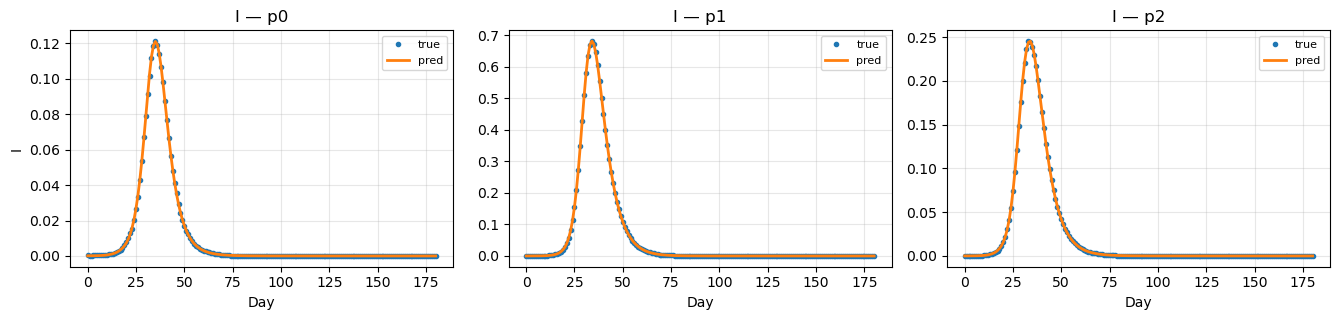

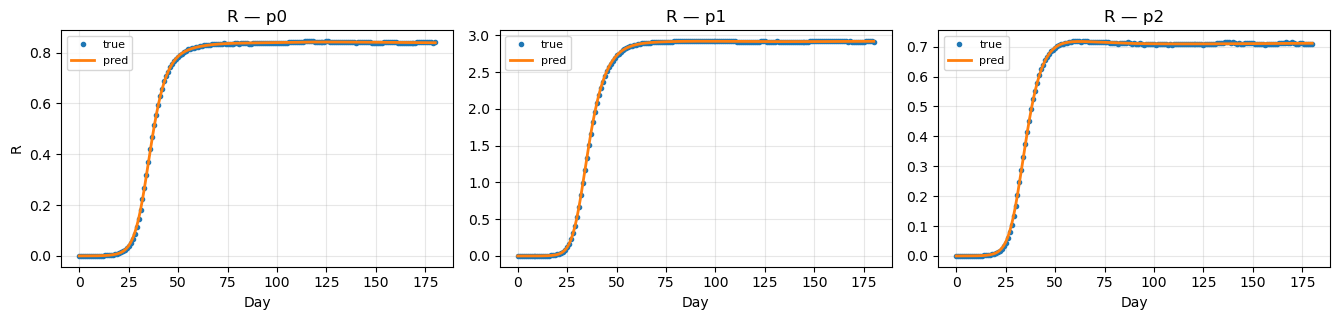

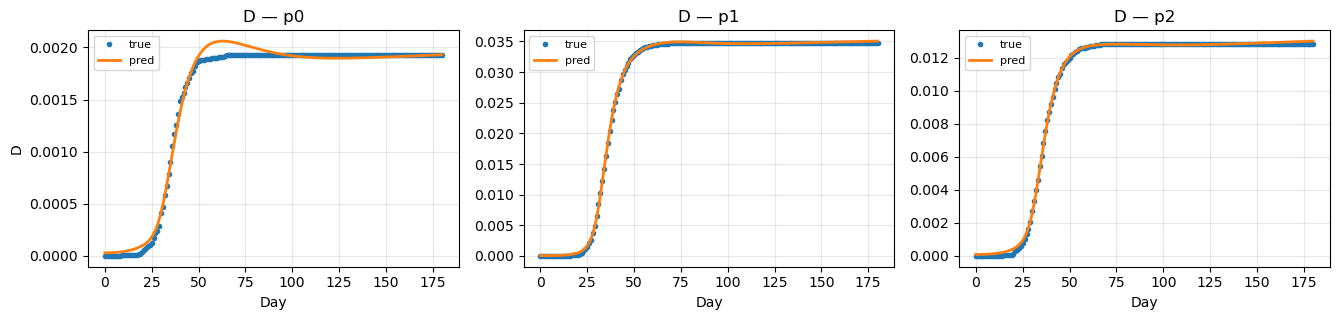

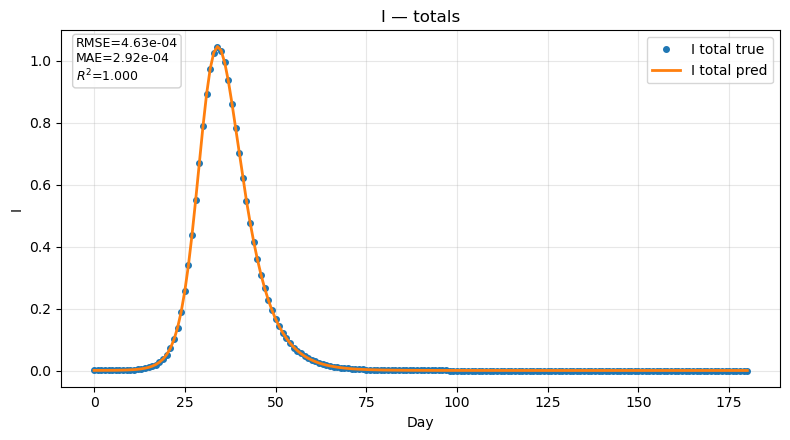

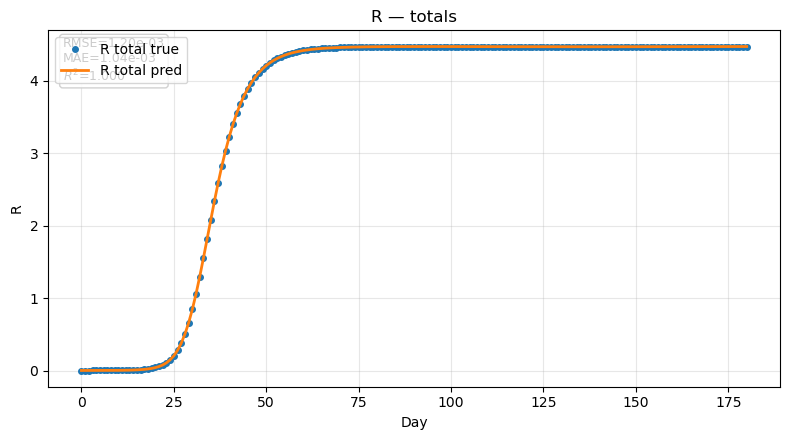

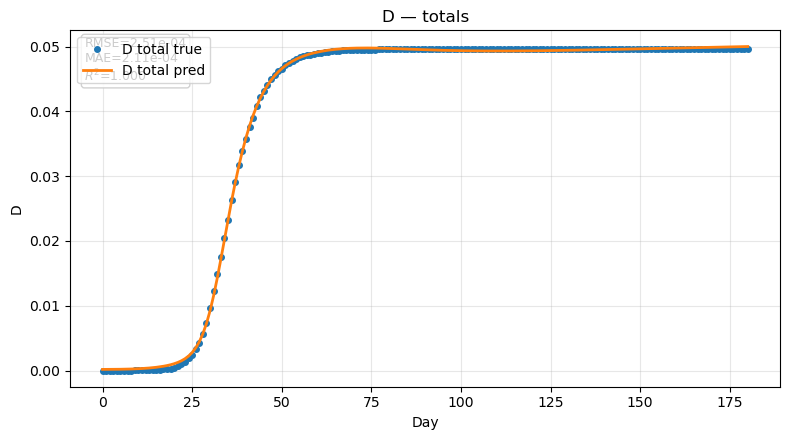

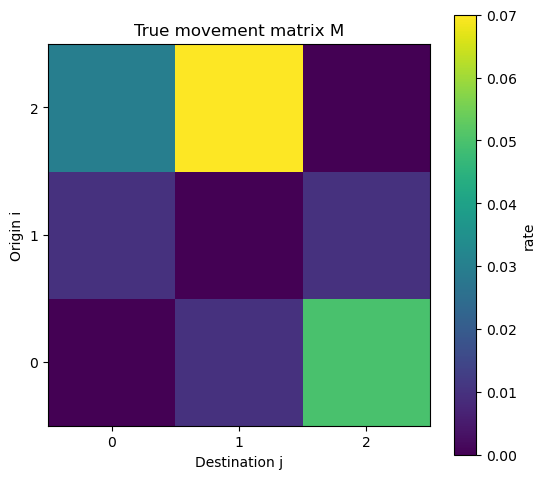

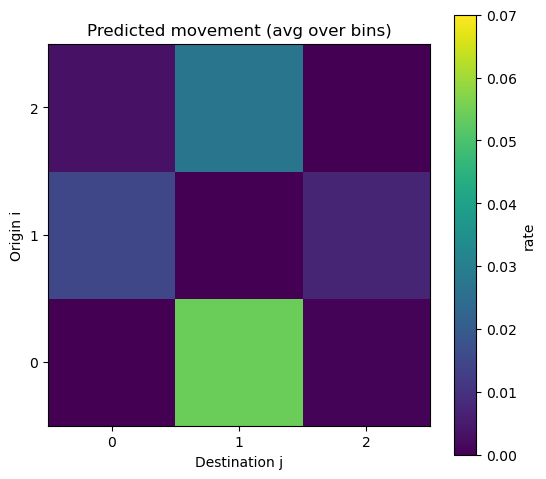

In [6]:
# True matrix from your simulator:
M_true = M.copy()  # (P,P)

# Predicted movement: if B_bins>1, average them (or plot each bin separately)
M_pred_avg = average_M_bins(M_bins)  # (P,P)

# Use a common color scale so the two heatmaps are comparable
vmax = max(M_true.max(), M_pred_avg.max())
vmin = 0.0

# Per-patch overlays
plot_grid_overlays(t_star, I_star, I, label='I')
plot_grid_overlays(t_star, R_star, R, label='R')
plot_grid_overlays(t_star, D_star, D, label='D')

# Totals
plot_totals_overlay(t_star, I_star, R_star, D_star, I, R, D, which='I')
plot_totals_overlay(t_star, I_star, R_star, D_star, I, R, D, which='R')
plot_totals_overlay(t_star, I_star, R_star, D_star, I, R, D, which='D')

# Movement (avg over bins)
M_pred_avg = average_M_bins(M_bins)
vmax = max(M_true.max(), M_pred_avg.max()); vmin = 0.0
plot_matrix_heatmap(M_true,     title="True movement matrix M", vmin=vmin, vmax=vmax)
plot_matrix_heatmap(M_pred_avg, title="Predicted movement (avg over bins)", vmin=vmin, vmax=vmax)
# Optional identity scatter:
# scatter_matrix_pred_vs_true(M_true, M_pred_avg, mask_diag=True)


[β] MAE=6.377e-02


(<Figure size 700x420 with 2 Axes>,
 array([<AxesSubplot:title={'center':'Recovery rate $\\gamma_p$'}, ylabel='Rate (1/day)'>,
        <AxesSubplot:title={'center':'Death rate $\\mu_p$'}>], dtype=object))

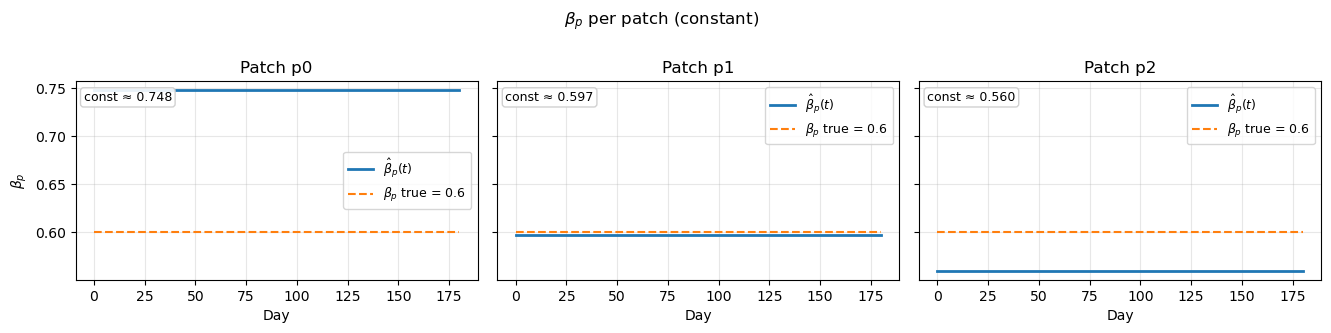

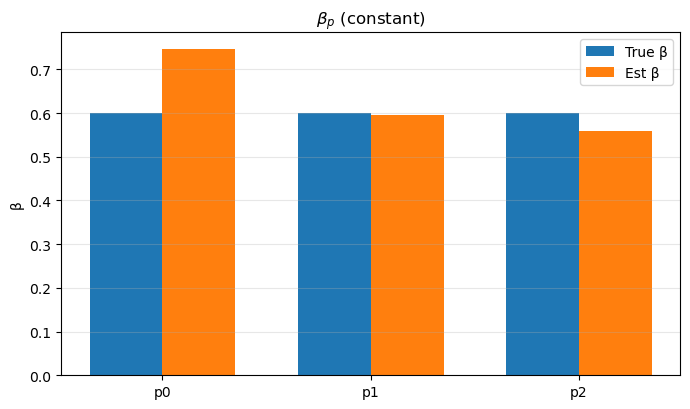

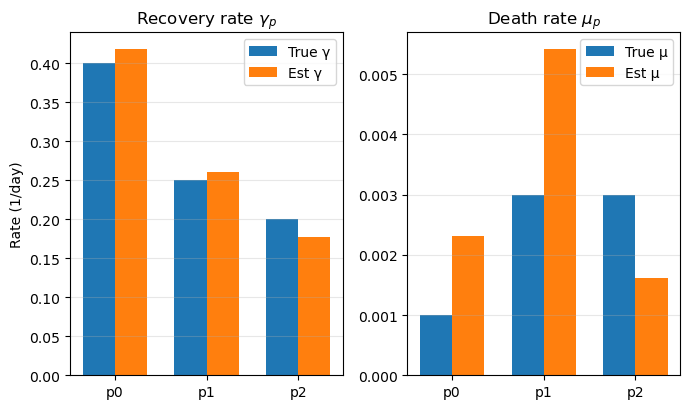

In [9]:
# Time-series view (shows flat lines, annotates the constant):
plot_beta_vs_true(t_star, Beta, beta_true=0.60, title=r"$\beta_p$ per patch (constant)")

# Or a compact bar chart (recommended for constant β):
pars = model.patch_params()              # has "beta" if you added it in the model
beta_const = pars["beta"] if "beta" in pars else Beta.mean(axis=0)
plot_beta_constants(beta_const, beta_true=0.60, title=r"$\beta_p$ (constant)")

# 4) γp and μp per patch (use scalars or per‑patch truth)
pars = model.patch_params()  # {"gamma": (P,), "mu": (P,)}
bar_gamma_mu(gamma, mu, pars["gamma"], pars["mu"])

